# Analysis Notebook Template   

copy of injection_and_recovery_v2

In [1]:
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, RectangularAperture
from test_analysis import read_in_fits
from analysis_functions import *

## Load data

In [3]:
TRIM_FRAMES = (199,-1)

In [4]:
data = read_in_fits('./data/260203/highAM_3')

Processing 1500 FITS files from ./data/260203/highAM_3
Loaded 1500 FITS files from ./data/260203/highAM_3


In [5]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what the channel looks like 

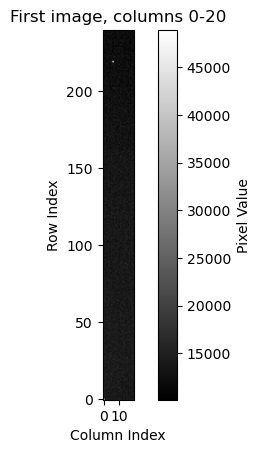

In [6]:
plt.imshow(data[0,:, :20], origin='lower', cmap='gray')
plt.title('First image, columns 0-20')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.colorbar(label='Pixel Value')
plt.show()

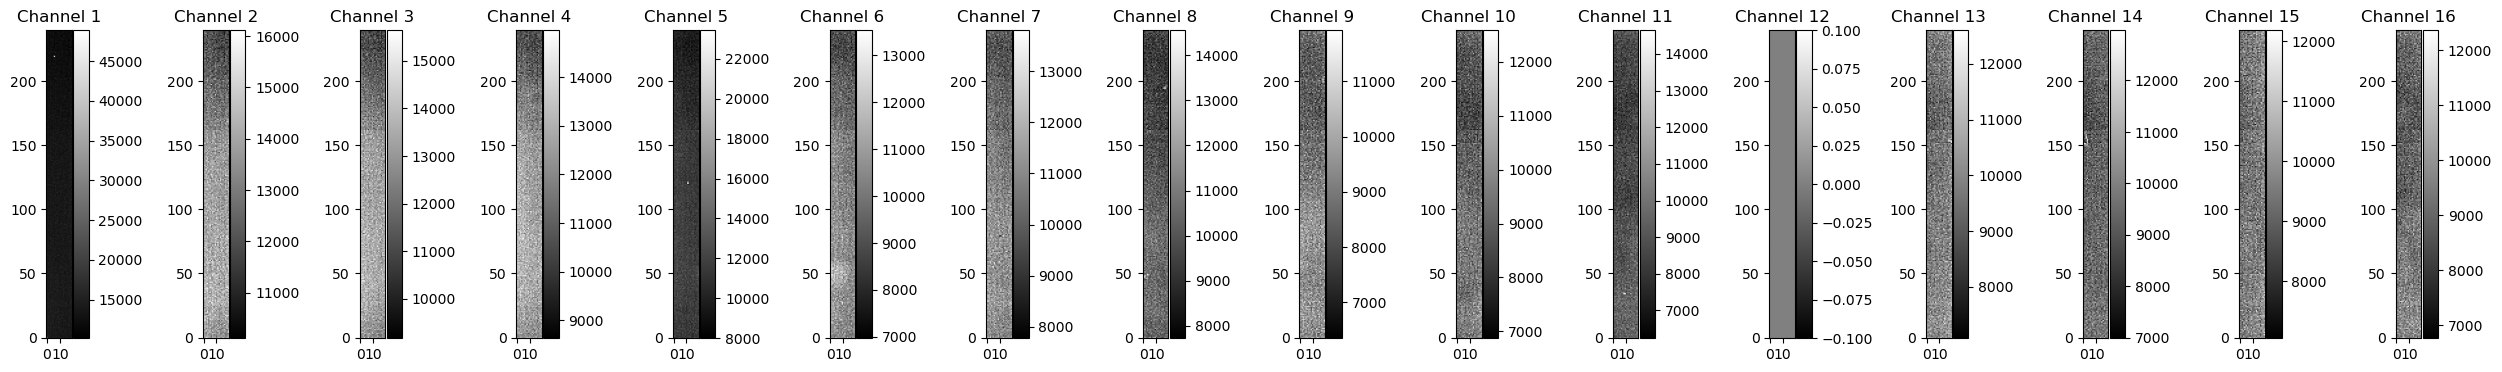

In [7]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

## First ## Compute $R(f_c)$

### First define an aperture andf compute the measured variance $\sigma^2(f_c)$ within it

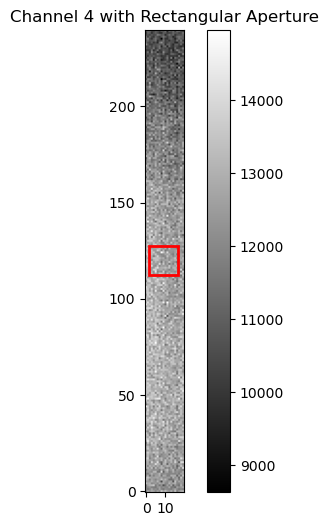

In [8]:
# Take the 4th channel and define a rectangular aperture of radius of size 8 x 8 pixels centered on the middle of the image (no annulus for background subtraction)
channel_4_data = channel_data[3]
aperture = RectangularAperture((9,120), 15, 15) 
# display aperture 
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(channel_4_data[0], cmap='gray', origin='lower')
aperture.plot(color='red', lw=2, ax=ax)
ax.set_title("Channel 4 with Rectangular Aperture")
plt.colorbar(im, ax=ax)
plt.show()  

In [9]:
result = extract_channels(data, channel_width=20, trim=TRIM_FRAMES)

In [10]:
coadds = np.arange(5,300)

In [11]:
ap = RectangularAperture((9, 120), 15, 15)

### PSD calculation for the signals (Welch's Method)

As a first pass at the data, we use the PSD to look for anything telling in the data

In [12]:
psd_freqs, psd_vals = psd_welch(result["channels"], frame_dt_s=0.0103, aperture=ap)

/tmp/ipykernel_2060129/3829742711.py:14: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


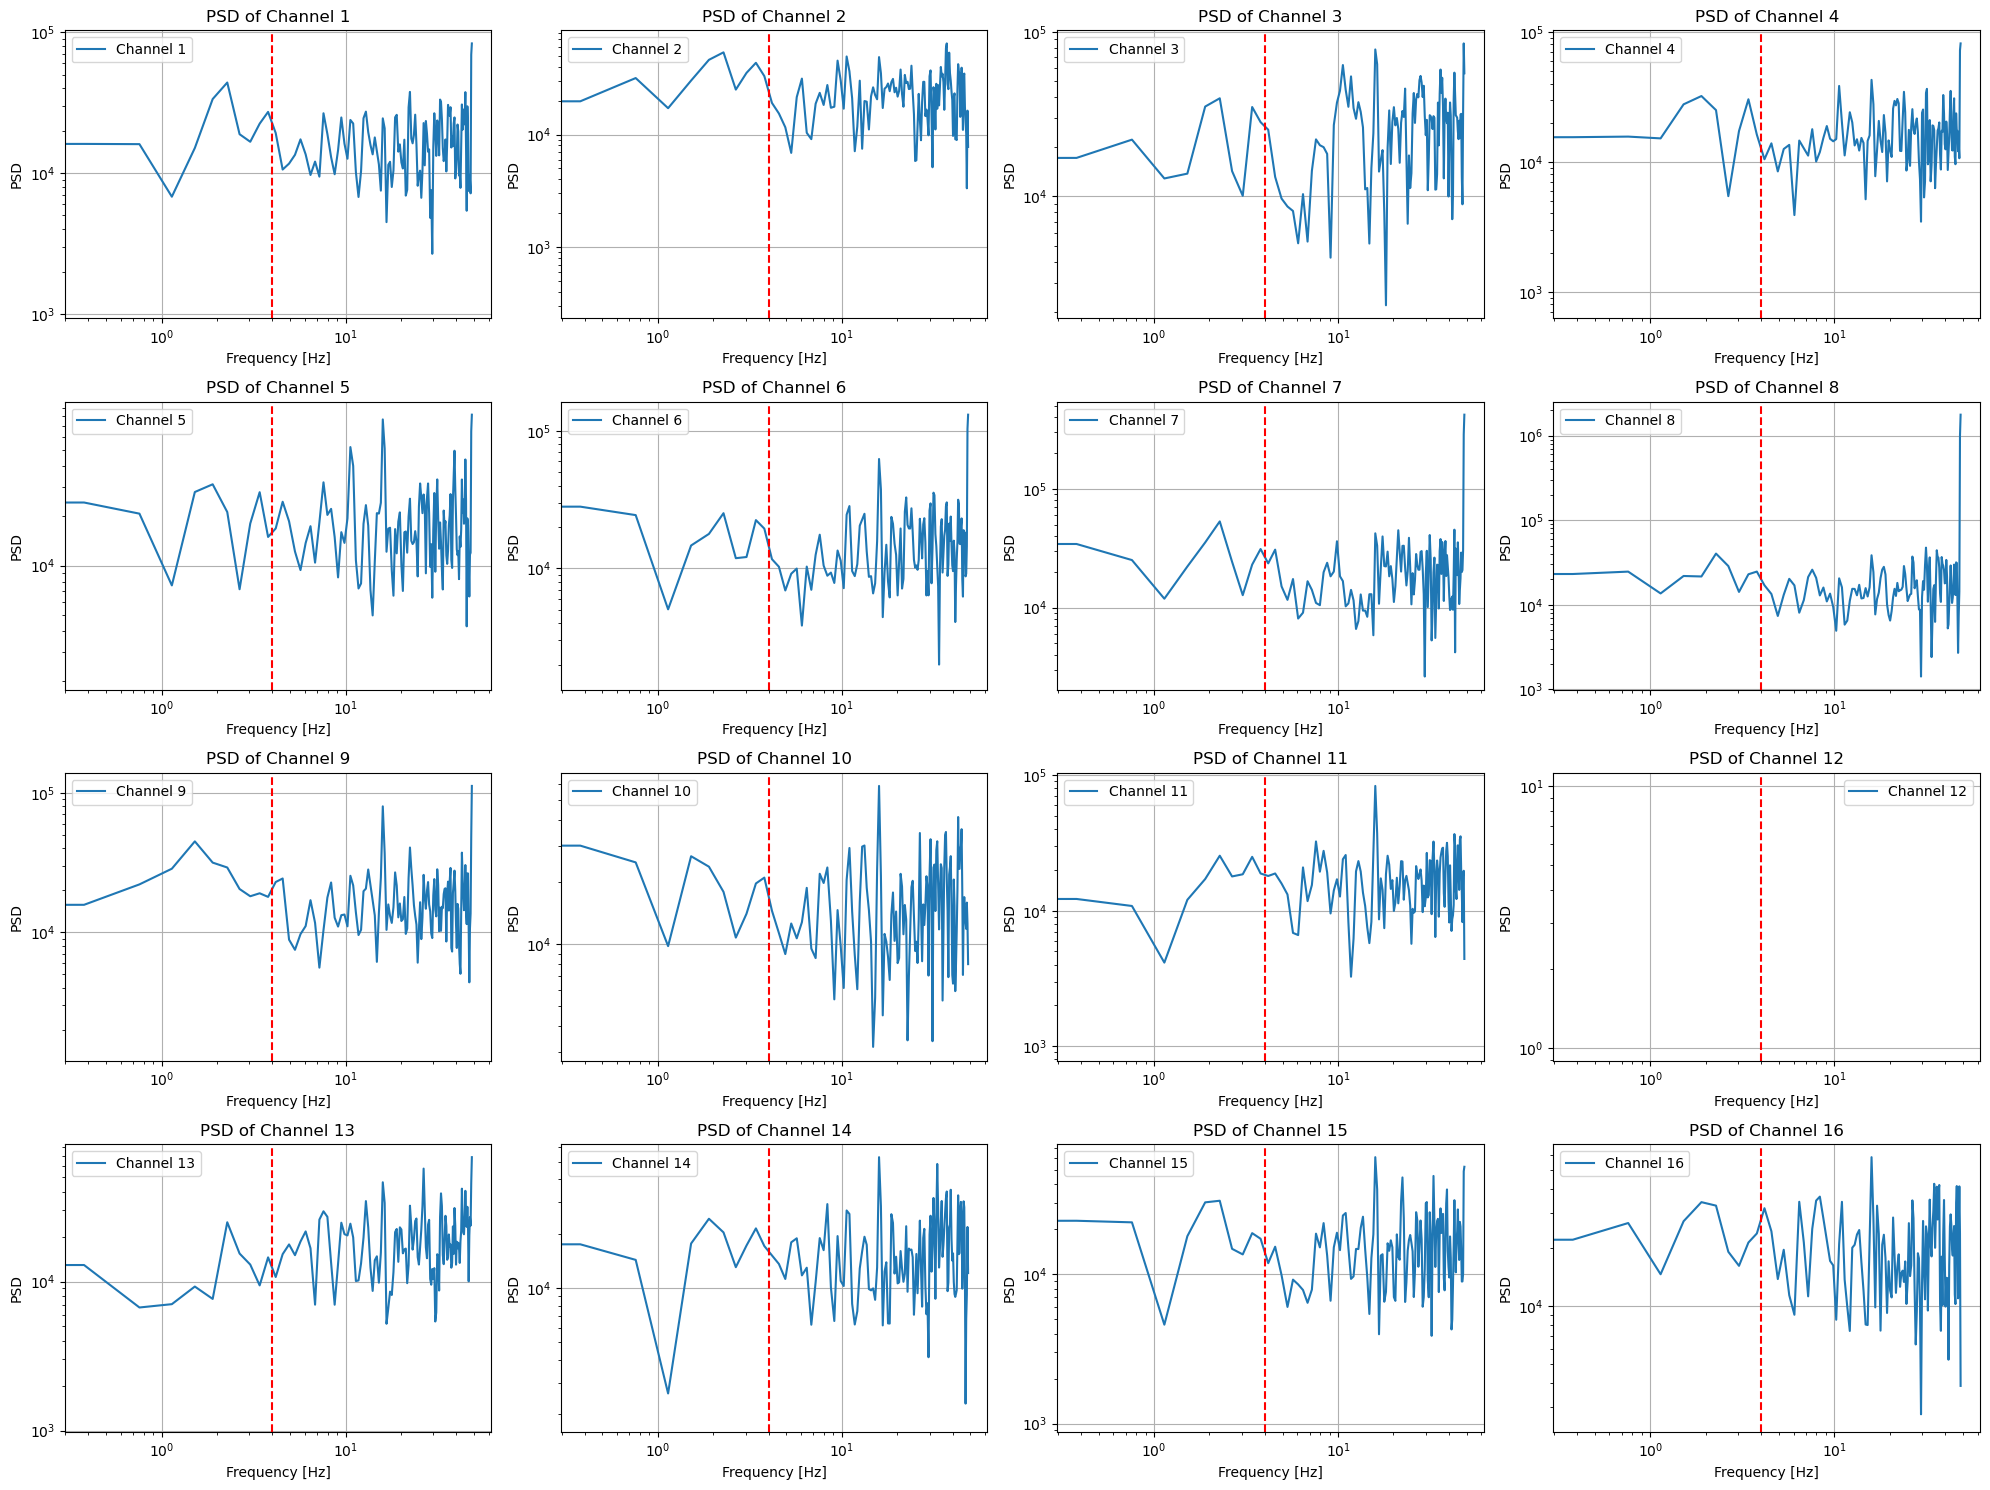

In [13]:
# Plot the psd 
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for i in range(num_channels):
    ax = axes[i//4, i%4]
    freqs = psd_freqs[i]
    psd = psd_vals[i]
    ax.plot(freqs, psd, label=f'Channel {i+1}')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('PSD')
    ax.set_title(f'PSD of Channel {i+1}')
    ax.grid(True)
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(4, color='red', linestyle='--', label='Injected Frequency')
plt.tight_layout()
plt.show()

### Build Variance Curves

In [14]:
variances, t_dwell, f_state, f_coadd, = create_variance_curve(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)


In [15]:
# Build timeseries dictionary for bootstrap analysis
timeseries_by_coadd, meta = build_timeseries_by_coadd(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)

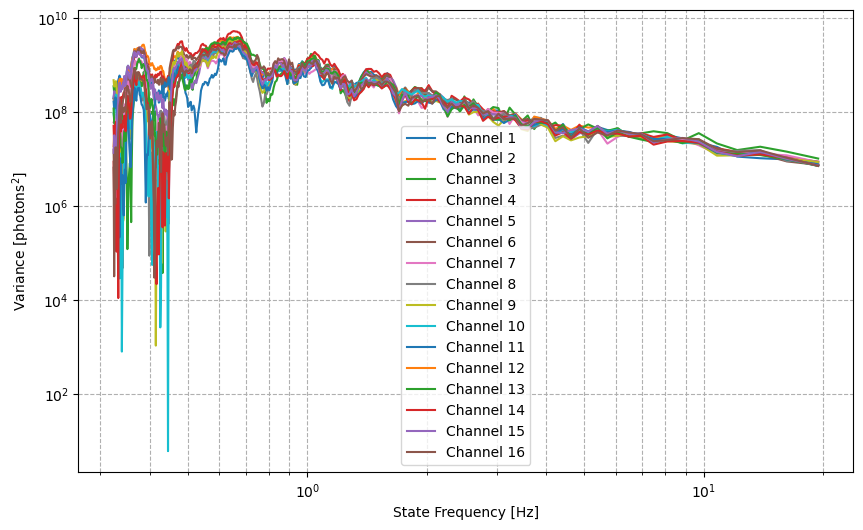

In [16]:
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):  
    channel_variance = [variances[i][channel] for i in range(len(coadds))]
    plt.plot(f_state, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency [Hz]')
plt.ylabel(r'Variance [photons$^2$]')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

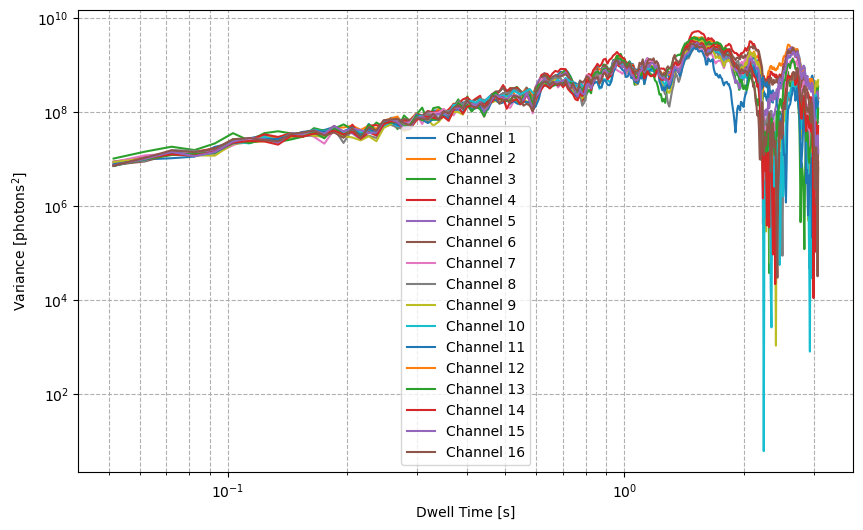

In [17]:
# Plot by dwell time instead 
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):
    channel_variance = [variances[i][channel] for i in range(len(coadds))]
    plt.plot(t_dwell, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Dwell Time [s]')
plt.ylabel(r'Variance [photons$^2$]')
# plt.title('Variance vs Dwell Time for Each Channel')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Error Estimation on Variance Measurements

We estimate errors on variance measurements using several methods:
1. **Sample count method**: Uses $\sigma(\text{var}) = \text{var} \times \sqrt{2/(N-1)}$ where N is the number of chopped pairs
2. **Bootstrap resampling**: Empirically estimates errors by resampling the data
3. **Channel-to-channel scatter**: Uses standard error across independent channels

In [18]:
errors_by_sample_count = compute_variance_errors_from_sample_count(variances, coadds, n_frames=result["channels"].shape[1])

In [19]:
errors_by_bootstrap = bootstrap_variance_by_coadd(timeseries_by_coadd, n_bootstrap=500)

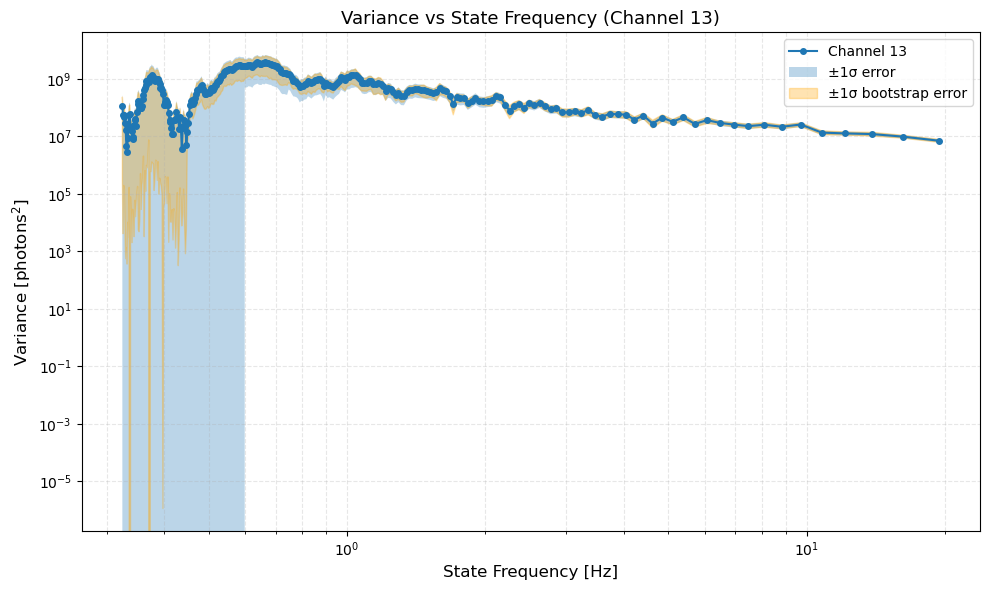

In [20]:
# Plot the results from just Channel 13 as an example 
# Use fill_between for shaded error region - much cleaner than error bars
channel = 12  # Example: Channel 13

channel_variance = np.array([variances[i][channel] for i in range(len(coadds))])
channel_errors_sample = np.array([errors_by_sample_count[i][channel] for i in range(len(coadds))])
channel_errors_bootstrap = np.array([errors_by_bootstrap[coadds[i]][channel] for i in range(len(coadds))])
f_state_array = np.array(f_state)

plt.figure(figsize=(10, 6))
plt.plot(f_state_array, channel_variance, marker='o', markersize=4, 
         linewidth=1.5, label=f'Channel {channel+1}', zorder=3)
plt.fill_between(f_state_array, 
                 channel_variance - channel_errors_sample, 
                 channel_variance + channel_errors_sample, 
                 alpha=0.3, label='±1σ error')
plt.fill_between(f_state_array, 
                 channel_variance - channel_errors_bootstrap, 
                 channel_variance + channel_errors_bootstrap,
                 alpha=0.3, label='±1σ bootstrap error', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency [Hz]', fontsize=12)
plt.ylabel(r'Variance [photons$^2$]', fontsize=12)
plt.title(f'Variance vs State Frequency (Channel {channel+1})', fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

It seems like the two methods yield largely the same results. Plot data from every channel to be sure


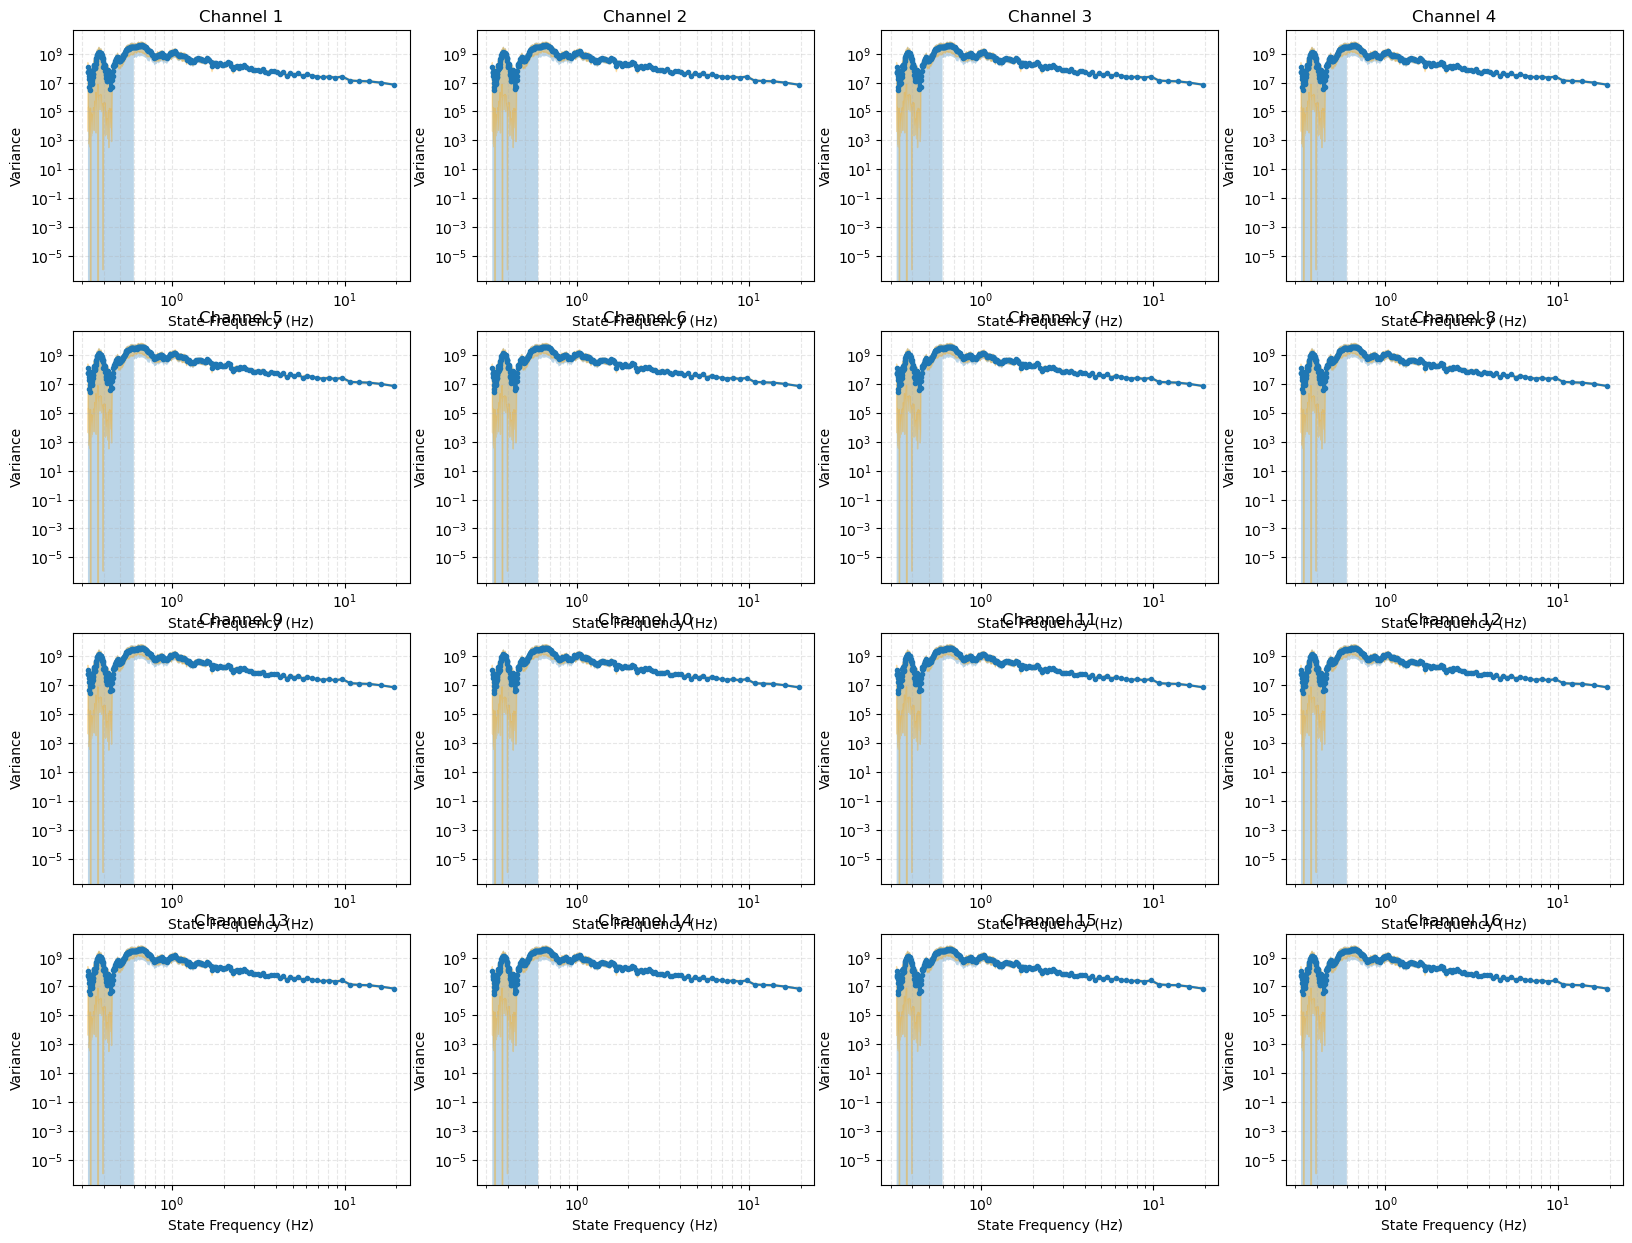

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):  
    ax = axes[channel//4, channel%4]
    
    ax.fill_between(f_state, channel_variance - channel_errors_sample, channel_variance + channel_errors_sample, alpha=0.3)
    ax.fill_between(f_state, channel_variance - channel_errors_bootstrap, channel_variance + channel_errors_bootstrap, alpha=0.3, color='orange')
    ax.plot(f_state, channel_variance, marker='o', markersize=3, linewidth=1.5)
    
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.3)

We can use the bootstrapped error for now as I think that will be better

In [22]:
# Define the frequency of the object - sky subtraction (0.5 Hz)

f_OS = 0.5 
sky_variances_at_f_OS = []

for channel in range(result["channels"].shape[0]):
    ch_variance = [variances[i][channel] for i in range(len(coadds))]

    # np.interp requires x-values in increasing order, but f_state is decreasing
    # So we need to reverse both arrays
    f_state_reversed = np.array(f_state)[::-1]
    ch_variance_reversed = np.array(ch_variance)[::-1]
    
    variance_at_f_OS = np.interp(f_OS, f_state_reversed, ch_variance_reversed)
    sky_variances_at_f_OS.append(variance_at_f_OS)

sky_variances_at_f_OS = np.array(sky_variances_at_f_OS, dtype=float)

/tmp/ipykernel_2060129/311154010.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


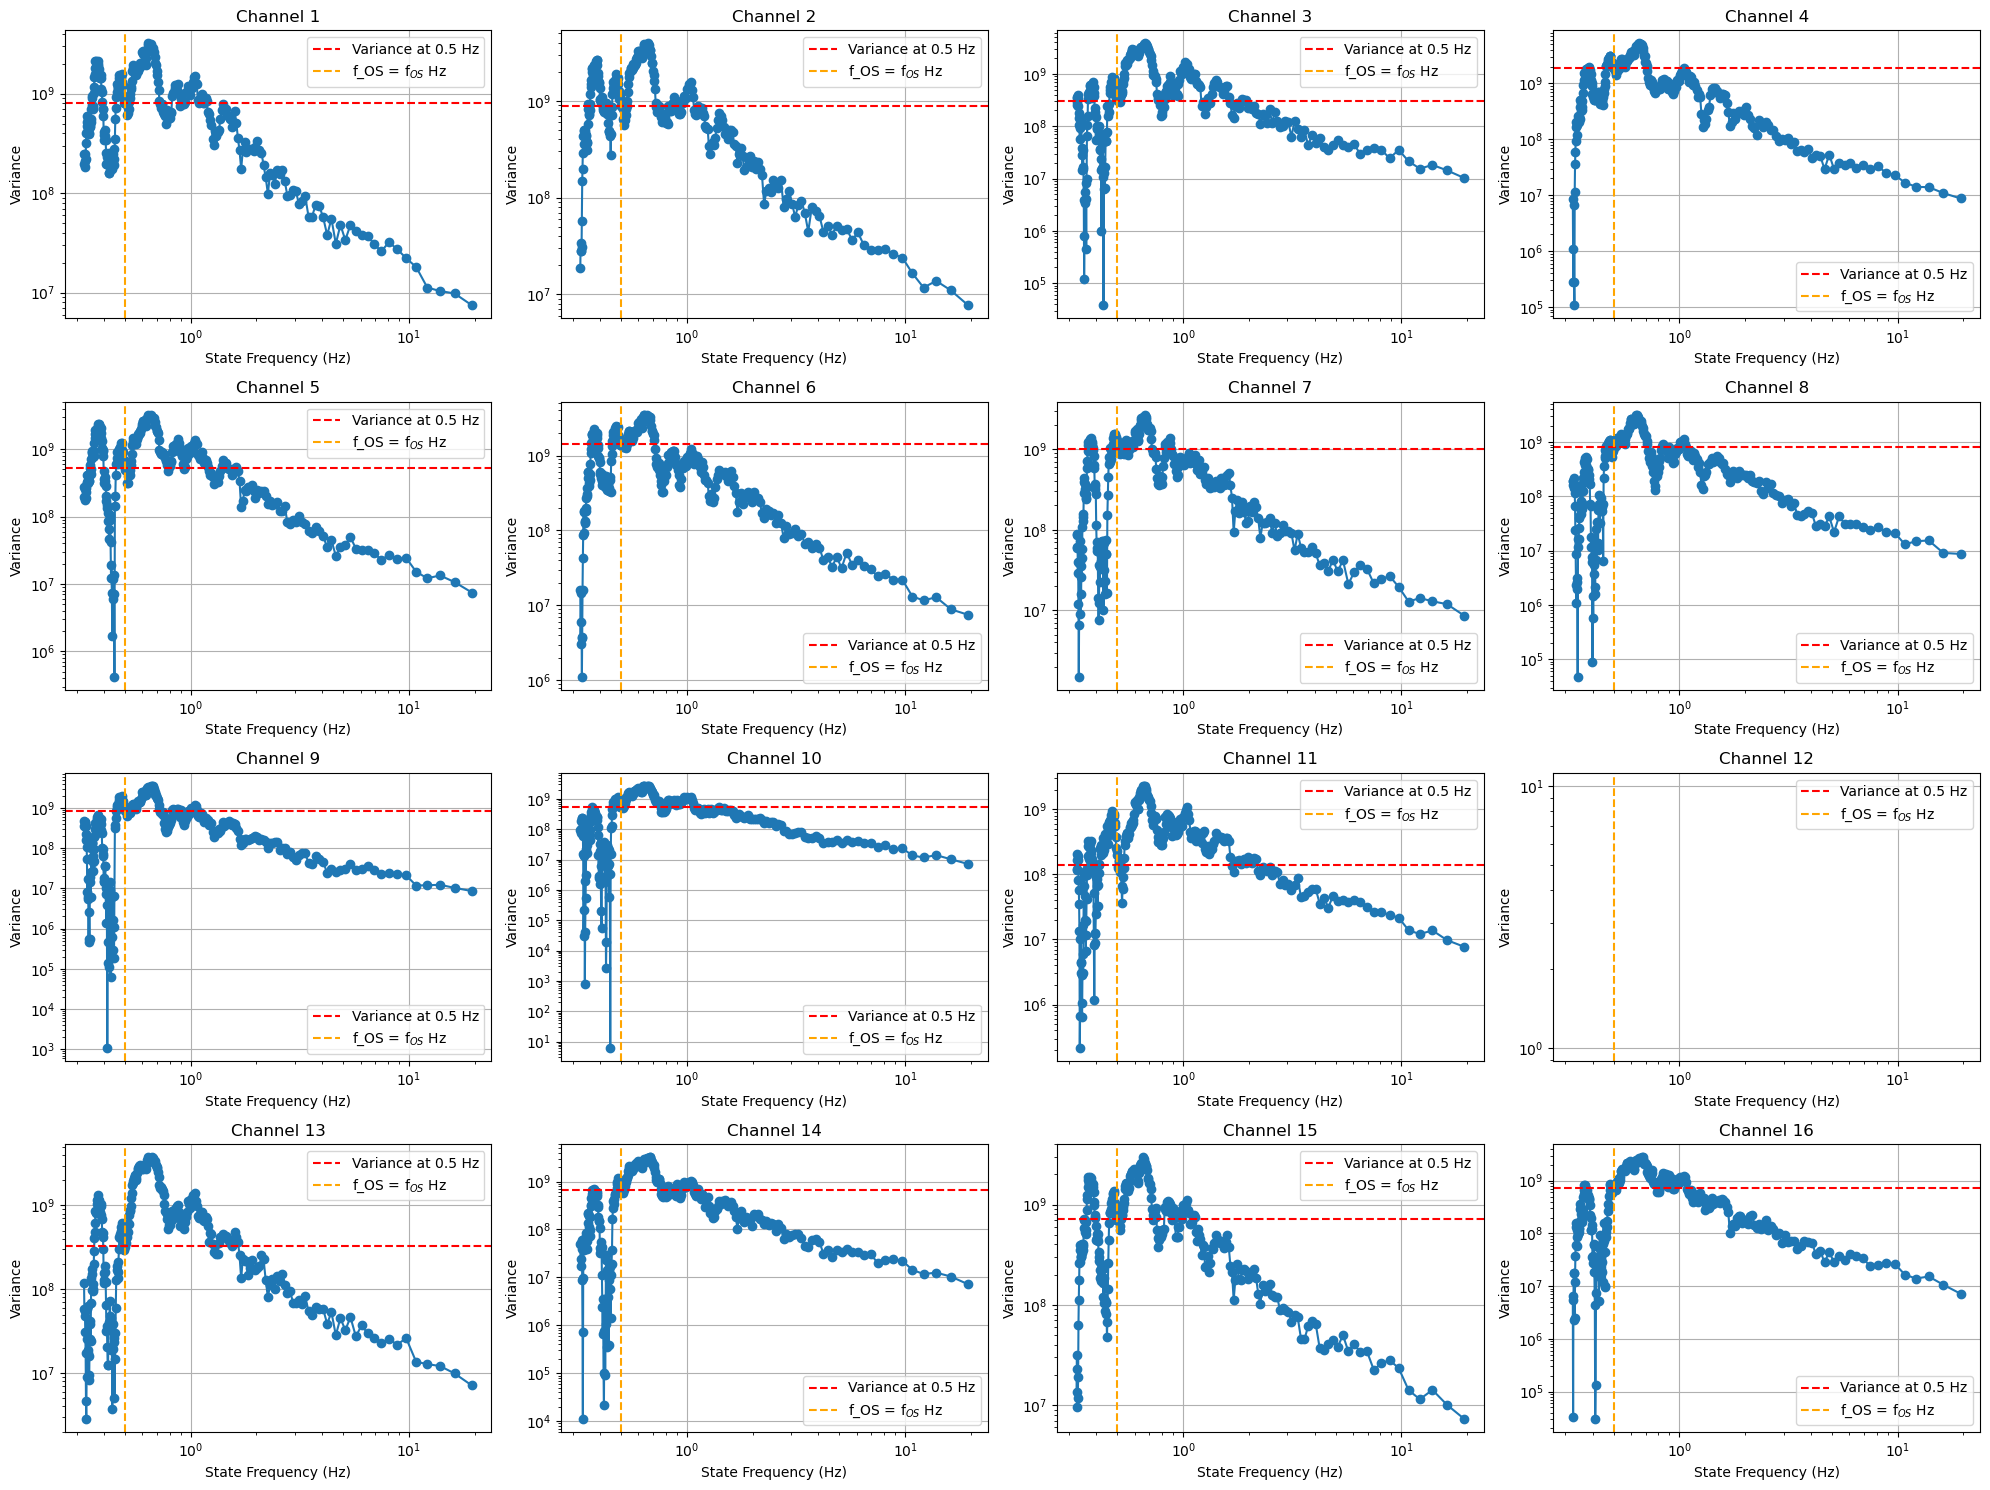

In [23]:
# For each channel, plot the variace curve and mark the variance at f_OS
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[i][channel] for i in range(len(coadds))]
    ax.plot(f_state, ch_variance, marker='o')
    ax.axhline(sky_variances_at_f_OS[channel], color='red', linestyle='--', label=f'Variance at {f_OS} Hz')
    ax.axvline(f_OS, color='orange', linestyle='--', label=r'f_OS = f$_{OS}$ Hz')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    #ax.set_xscale('log')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

Now, in each channel, divide by the variance at that value to get the normalized variance curve in terms of the "R" parameter.

In [24]:
ch_var_matrix = np.array([[variances[i][channel] for i in range(len(coadds))]
                          for channel in range(result["channels"].shape[0])], dtype=float)
# Safe divide; invalid denominators become NaN
den = sky_variances_at_f_OS[:, None]
R_factor = np.divide(
    ch_var_matrix, den,
    out=np.full_like(ch_var_matrix, np.nan),
    where=np.isfinite(den) & (den > 0)
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


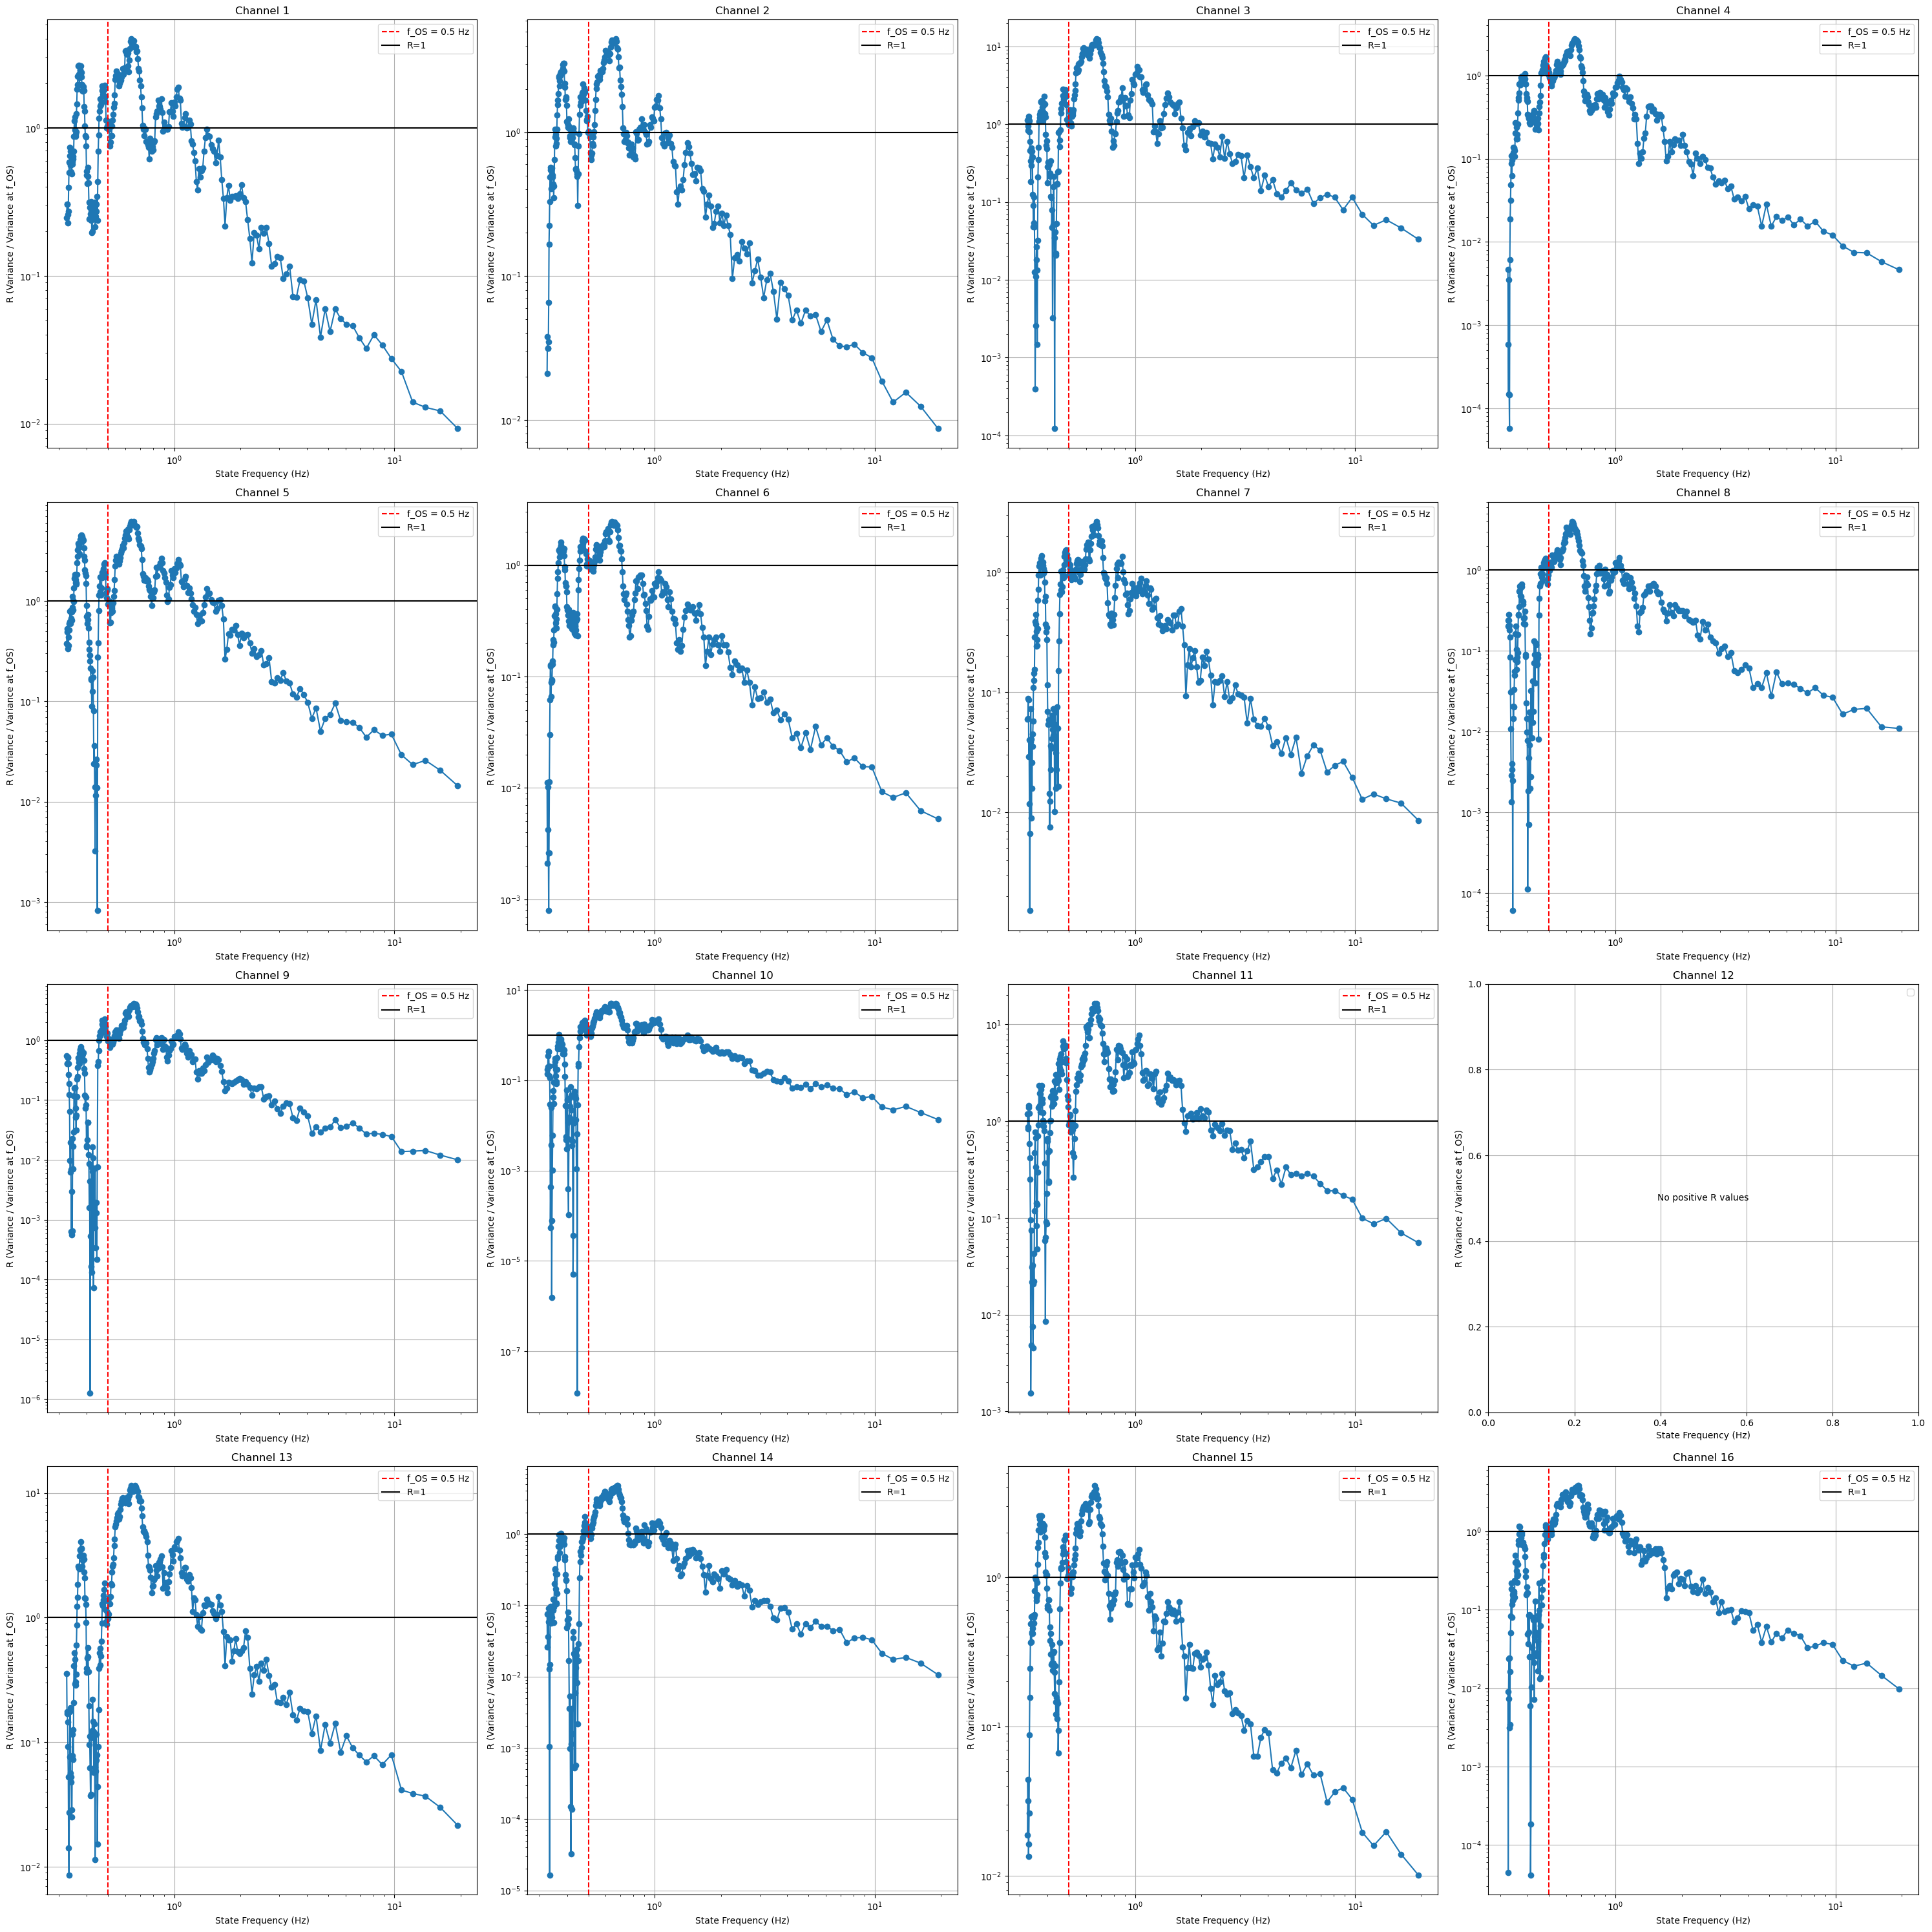

In [25]:
# Double check the shape of the R factor matrix and then plot 
assert R_factor.shape == ch_var_matrix.shape == (16, len(coadds))

# Great, let's repeat the plot but using marking the F_OS point with a vertical dashed line, a black horizontal line ar R = 1, and a red fill (for the entire region) for R > 1 and a light green fill for R < 1 with text that says "no chopping improvment" 
fig, axes = plt.subplots(4, 4, figsize=(30,30))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')

        # Add vertical line at f_OS
        ax.axvline(f_OS, color='red', linestyle='--', label=f'f_OS = {f_OS} Hz')

        # Add horizontal line at R=1
        ax.axhline(1, color='black', linestyle='-', label='R=1')

    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()


### Error Propagation for R-factor

The R-factor is defined as $R(f_c) = \sigma^2(f_c) / \sigma^2(f_{OS})$

Using error propagation: $\sigma(R) = R \times \sqrt{\left(\frac{\sigma(\text{var})}{\text{var}}\right)^2 + \left(\frac{\sigma(\text{var}_{\text{ref}})}{\text{var}_{\text{ref}}}\right)^2}$

In [26]:
# Compute errors on the reference variance (at f_OS)
# Find which coadd gives f_state closest to f_OS
f_state_array = np.array(f_state)
idx_f_OS = np.argmin(np.abs(f_state_array - f_OS))

# Error on reference variance for each channel
var_ref_errors = errors_by_bootstrap[coadds[idx_f_OS]]

# Now compute R-factor errors using error propagation
R_factor_errors = np.zeros_like(R_factor)

for channel in range(result["channels"].shape[0]):
    for i in range(len(coadds)):
        var_i = variances[i][channel]
        var_err_i = errors_by_bootstrap[coadds[i]][channel]
        var_ref = sky_variances_at_f_OS[channel]
        var_ref_err = var_ref_errors[channel]
        R = R_factor[channel, i]
        
        if np.isfinite(R) and var_i > 0 and var_ref > 0:
            # Error propagation for ratio
            relative_error = np.sqrt((var_err_i / var_i)**2 + (var_ref_err / var_ref)**2)
            R_factor_errors[channel, i] = R * relative_error
        else:
            R_factor_errors[channel, i] = np.nan

print(f"R-factor errors computed for {np.sum(np.isfinite(R_factor_errors))} valid points")

R-factor errors computed for 4425 valid points


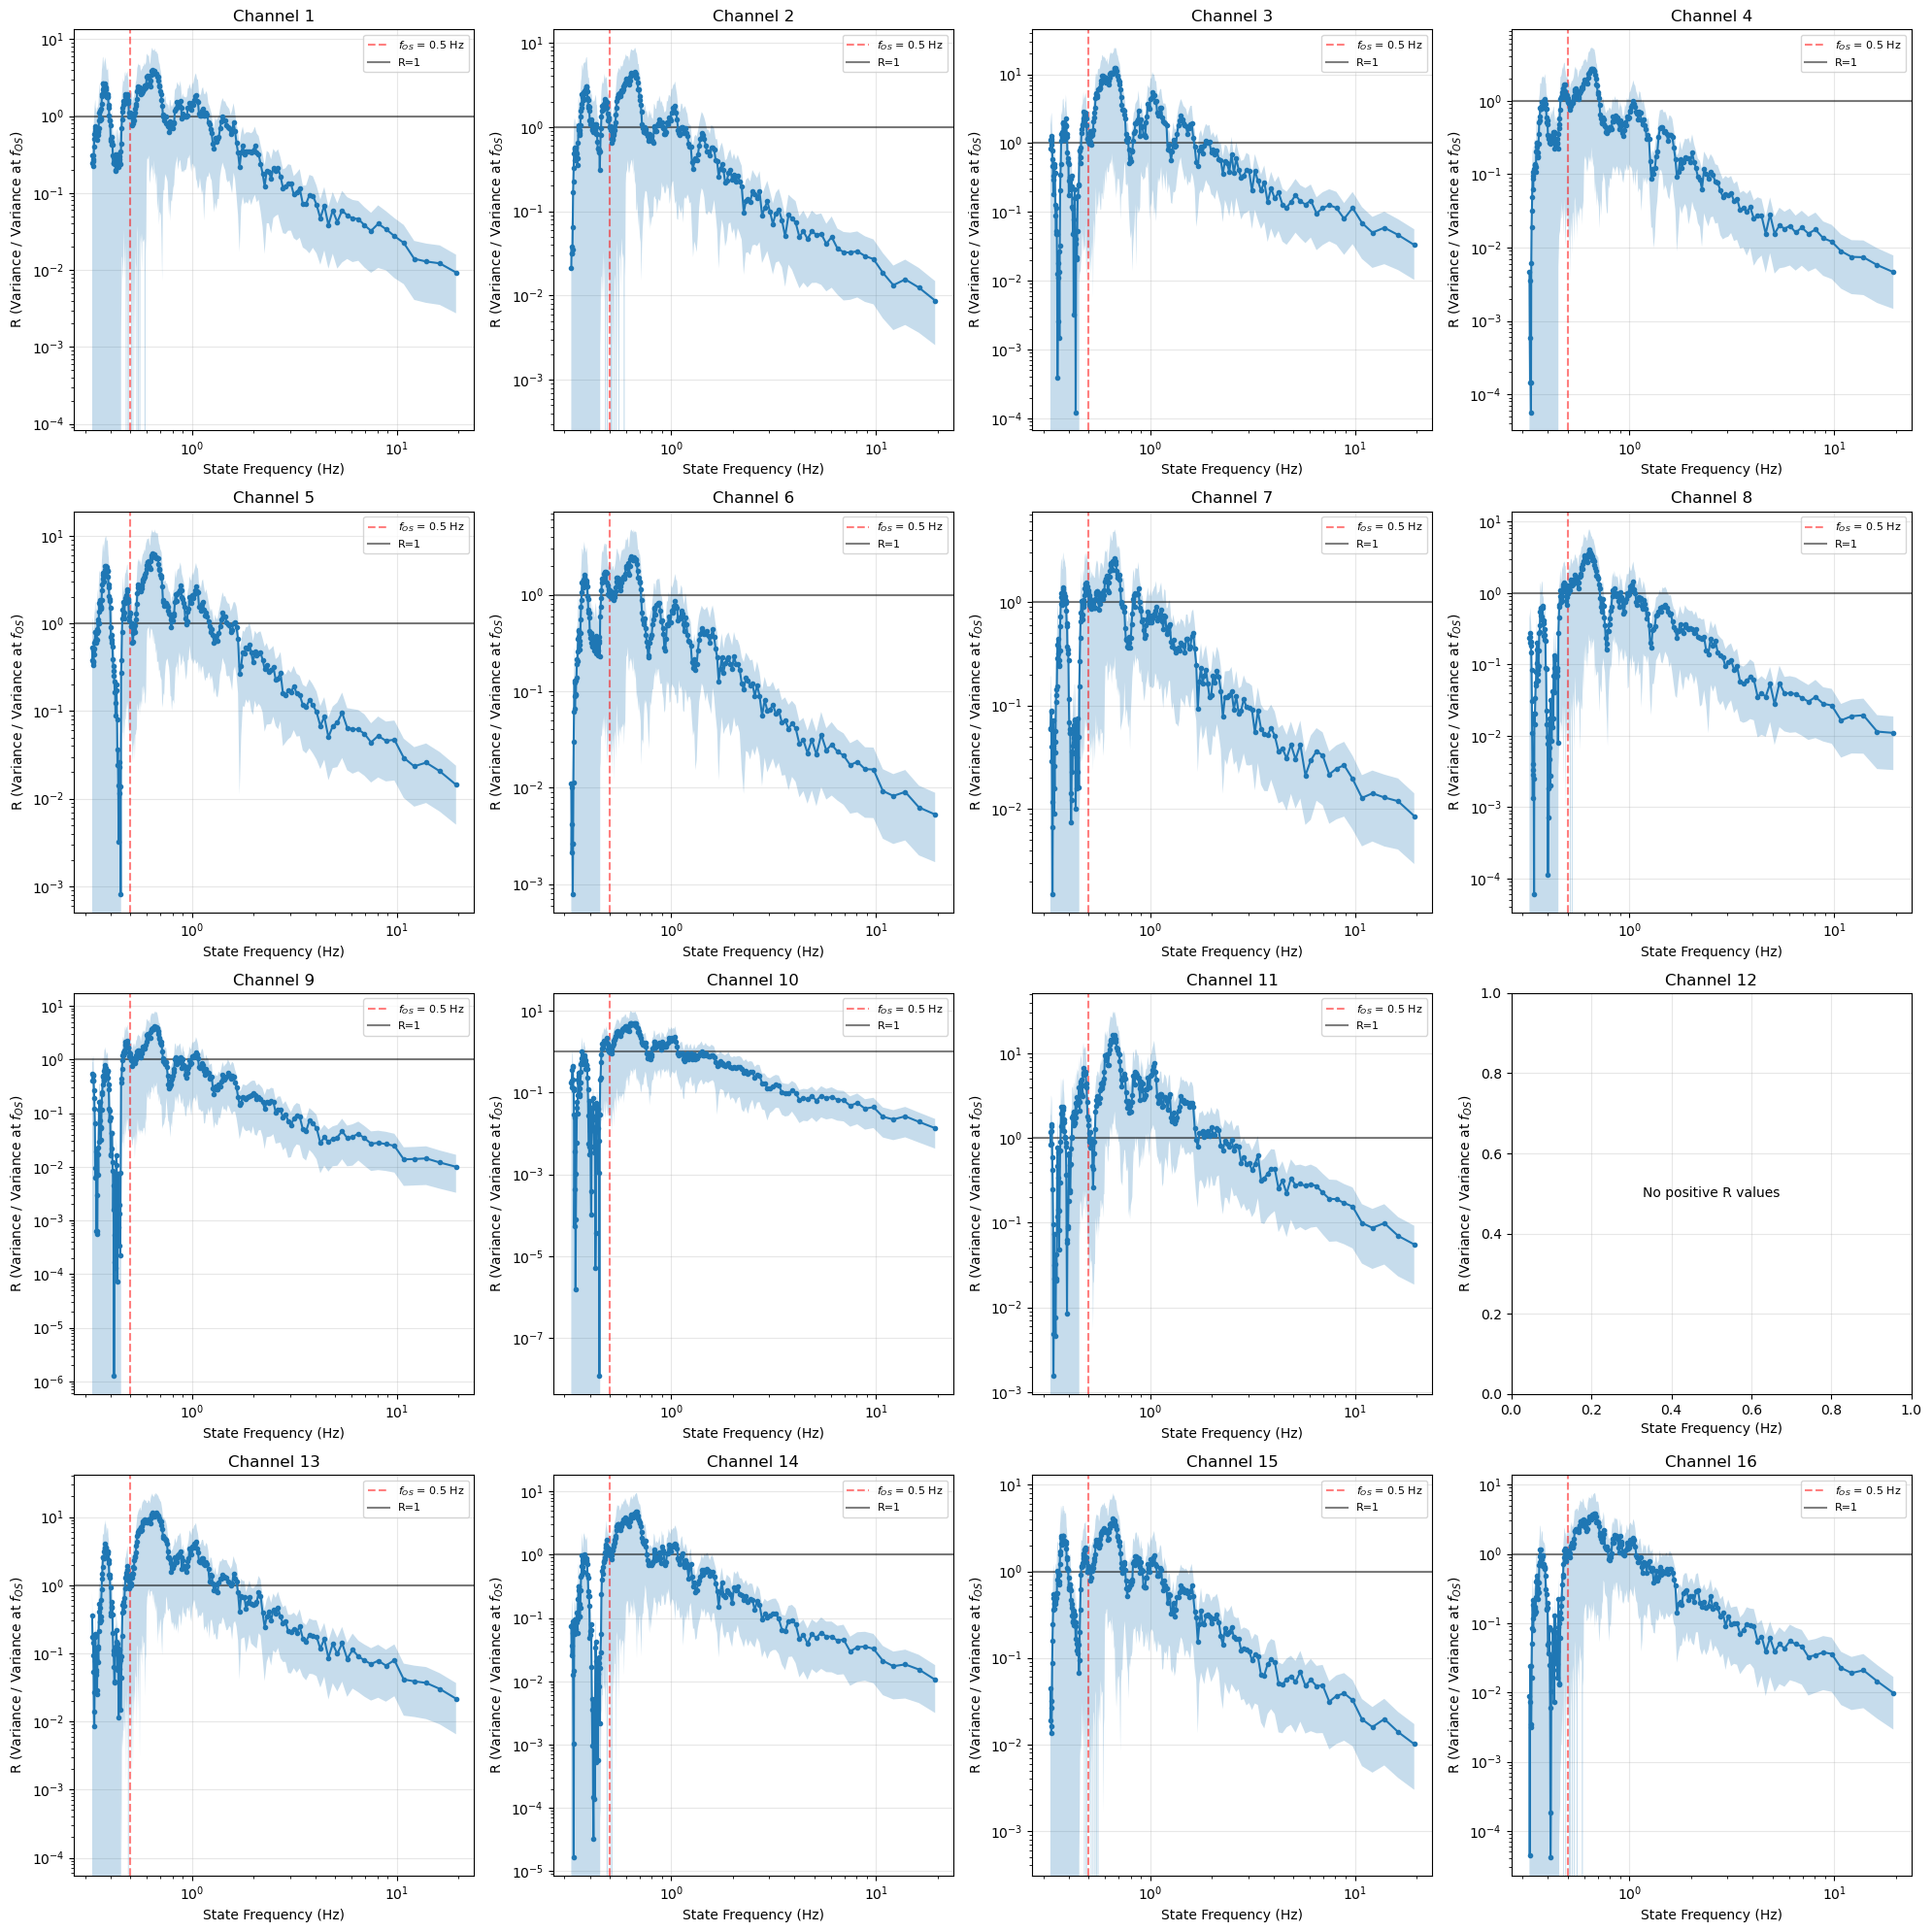

In [27]:
# Plot R-factor with shaded error regions - cleaner than error bars
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    R_errors = np.array(R_factor_errors[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = (np.isfinite(R_values) & (R_values > 0) & 
            np.isfinite(xvals) & (xvals > 0) & 
            np.isfinite(R_errors))

    if np.any(good):
        # Plot line with shaded error region
        ax.plot(xvals[good], R_values[good], linewidth=1.5, marker='o', 
                markersize=3, zorder=3)
        ax.fill_between(xvals[good], 
                        (R_values - R_errors)[good], 
                        (R_values + R_errors)[good], 
                        alpha=0.25, zorder=2)
        
        ax.set_xscale('log')
        ax.set_yscale('log')

        # Add vertical line at f_OS
        ax.axvline(f_OS, color='red', linestyle='--', alpha=0.5, linewidth=1.5, 
                   label=f'$f_{{OS}}$ = {f_OS} Hz')

        # Add horizontal line at R=1
        ax.axhline(1, color='black', linestyle='-', alpha=0.5, linewidth=1.5, 
                   label='R=1')
        
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', 
                transform=ax.transAxes)
    
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at $f_{OS}$)')
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

## Compute the fudicial sky rate

We use the sky emission python file to compute a fudicial rate for 

In [28]:
sky_rate = 2.425e9 #ph/s/m^2/arcsec^2
tel_rate = 1.511e9 #ph/s/m^2/arcsec^2

In [29]:
# Efficiency values
E_primary_mirror = 0.95
E_secondary_mirror = 0.98
E_dichroic = 0.94
E_ZnSe = 0.95
E_M1 = 0.95
E_M2 = 0.96 
E_Nband = 0.5 
E_BaF2 = 0.7 
E_cold_stop = 0.9
E_M3 = 0.96 
E_M4 = 0.96 
QE = 0.4

In [30]:
eta_tel = (E_secondary_mirror * E_dichroic * E_ZnSe * E_M1 * E_M2 * E_BaF2 * E_cold_stop * E_M3 * E_M4) # total telescope efficiency

In [31]:
print(f"Total telescope efficiency (eta_tel): {eta_tel:.3f}")

Total telescope efficiency (eta_tel): 0.463


In [32]:
sky_rate_after_efficiency = sky_rate * E_primary_mirror * eta_tel * QE

In [33]:
print(f"Sky rate after efficiency (sky_rate_after_efficiency): {sky_rate_after_efficiency:.3e} ph/s/m^2/arcsec^2")

Sky rate after efficiency (sky_rate_after_efficiency): 4.270e+08 ph/s/m^2/arcsec^2


In [34]:
pixel_scale_arcsec = 0.27 # arcsec/pixel
omega_pix = pixel_scale_arcsec ** 2  # arcsec^2/pixel

# Collecting area of IRTF
D = 3.2 # Meters 
A_tel = np.pi * (D / 2) ** 2  # m^2

# Total sky photons per pixel per second
sky_photons_per_pixel_per_second = sky_rate_after_efficiency * A_tel * omega_pix

print(f"Sky photons per second per pixel: {sky_photons_per_pixel_per_second:.3e} ph/s") 

Sky photons per second per pixel: 2.504e+08 ph/s


## Calcuation of $\sigma^2_{corr,ref}$

First, we compute the fractional change in the sky frames (within the aperture) at the characteristic O-S frequency. 

In [35]:
# Bin the data so that the state frequency is f_OS = 0.5 Hz, which means we need to bin every 1/f_OS = 2 seconds. With a frame time of 0.0103 seconds, that means we need to bin every 2 / 0.0103 ≈ 194 frames.
bin_size = int(2 / 0.0103)  # Number of frames to bin together to achieve f_OS = 0.5 Hz
binned_channels = []
for channel in range(result["channels"].shape[0]):
    ch_data = result["channels"][channel]
    num_bins = ch_data.shape[0] // bin_size
    binned_ch = ch_data[:num_bins * bin_size].reshape(num_bins, bin_size, *ch_data.shape[1:]).mean(axis=1)
    binned_channels.append(binned_ch)
binned_channels = np.array(binned_channels)

In [36]:
# for each binned channel find the average value of the pixel in the aperature and find the fractional variation of the pixel values in the aperture across all frames for that channel. Plot this fractional variation as a function of channel number to see if it correlates with the variance curves.
bad_channels = [11]
# Initialize array to store all the fractional variations for each channel
channel_var_del = np.zeros(binned_channels.shape[0])
for channel in range(binned_channels.shape[0]):
    if channel in bad_channels:
        print(f"Skipping Channel {channel+1} due to known issues.")
        continue
    # Initialize array for the stack variances for this channel should have shape (num_frames,)
    stack_variances = np.zeros(binned_channels.shape[1])
    # Loop over all frames in the channel compute the mean in the aperture and find the fractional change for every pixel 
    for i in range(binned_channels.shape[1]):
        # Create aperture
        ap = RectangularAperture((9, 120), 17, 17)
        mask = ap.to_mask(method='center')

        # Extract just the region inside the aperture
        # mask.bbox gives you the bounding box of the aperture
        cropped_frame = mask.multiply(binned_channels[channel, i])
        mean_ap = np.mean(cropped_frame[cropped_frame > 0]) # only take the mean of the pixels that are inside the aperture (non-zero values)
      
        # Now compute the fractional change for every pixel in the aperture and then compute the variance of the fractional change across all pixels in the aperture for this frame
        frac_change = (cropped_frame[cropped_frame > 0] - mean_ap) / mean_ap
        
        # Compute the variance of the fractional change across all pixels in the aperture for this frame and store it in the stack_variances array
        stack_variances[i] = np.var(frac_change)

    # Now we have the variance of the fractional change for each frame in this channel, we can compute the mean variance across all frames for this channel and store it in the channel_var_del array
    channel_var_del[channel] = np.mean(stack_variances)


Skipping Channel 12 due to known issues.


In [37]:
# Compute error on channel_var_del (standard error of the mean of stack_variances)
channel_var_del_errors = np.zeros(binned_channels.shape[0])
bad_channels = [11]

for channel in range(binned_channels.shape[0]):
    if channel in bad_channels:
        channel_var_del_errors[channel] = np.nan
        continue
    
    # Recompute stack_variances for this channel
    stack_variances = np.zeros(binned_channels.shape[1])
    for i in range(binned_channels.shape[1]):
        ap = RectangularAperture((9, 120), 17, 17)
        mask = ap.to_mask(method='center')
        cropped_frame = mask.multiply(binned_channels[channel, i])
        mean_ap = np.mean(cropped_frame[cropped_frame > 0])
        frac_change = (cropped_frame[cropped_frame > 0] - mean_ap) / mean_ap
        stack_variances[i] = np.var(frac_change)
    
    # Standard error of the mean
    channel_var_del_errors[channel] = np.std(stack_variances, ddof=1) / np.sqrt(len(stack_variances))

In [38]:
print("Fractional variation of pixel values in the aperture for each channel:")
for channel in range(result['channels'].shape[0]):
    if channel not in bad_channels:
        print(f"Channel {channel+1}: {channel_var_del[channel]}")

Fractional variation of pixel values in the aperture for each channel:
Channel 1: 0.005574157600574281
Channel 2: 0.004291040389452195
Channel 3: 0.005649647255646248
Channel 4: 0.006423978569351498
Channel 5: 0.02108758649032752
Channel 6: 0.010950896921608284
Channel 7: 0.006372998309260871
Channel 8: 0.007393846479792218
Channel 9: 0.012324904266681883
Channel 10: 0.01054838223026682
Channel 11: 0.012735570289874848
Channel 13: 0.00991677994926497
Channel 14: 0.012447795964362655
Channel 15: 0.013830521722132108
Channel 16: 0.012360959004292573


Now, compute the expected number of photosn from the 

In [39]:
var_corr_ref =((sky_photons_per_pixel_per_second / f_OS)**2) * channel_var_del

## Compute $\sigma^2_{corr}(f_c)$

Now, we compute the actual photon rate based on the model rates and the sigma values.

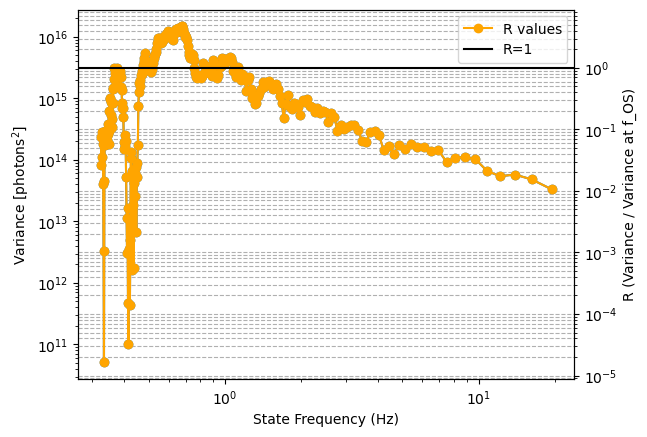

In [40]:
# Use channel 13 as an example 
expected_var_corr_ref = var_corr_ref[13] * R_factor[13, :]
plt.plot(f_state, expected_var_corr_ref, marker='o', label=f'Channel 13')
plt.yscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel(r'Variance [photons$^2$]')
# Use other y axiis to plot the actual R values on the same plot
plt.twinx()
plt.plot(f_state, R_factor[13, :], marker='o', color='orange', label='R values')
plt.axhline(1, color='black', linestyle='-', label='R=1')
plt.xscale('log')
plt.yscale('log')

plt.ylabel('R (Variance / Variance at f_OS)')
plt.grid(True, which="both", ls="--")
plt.legend()

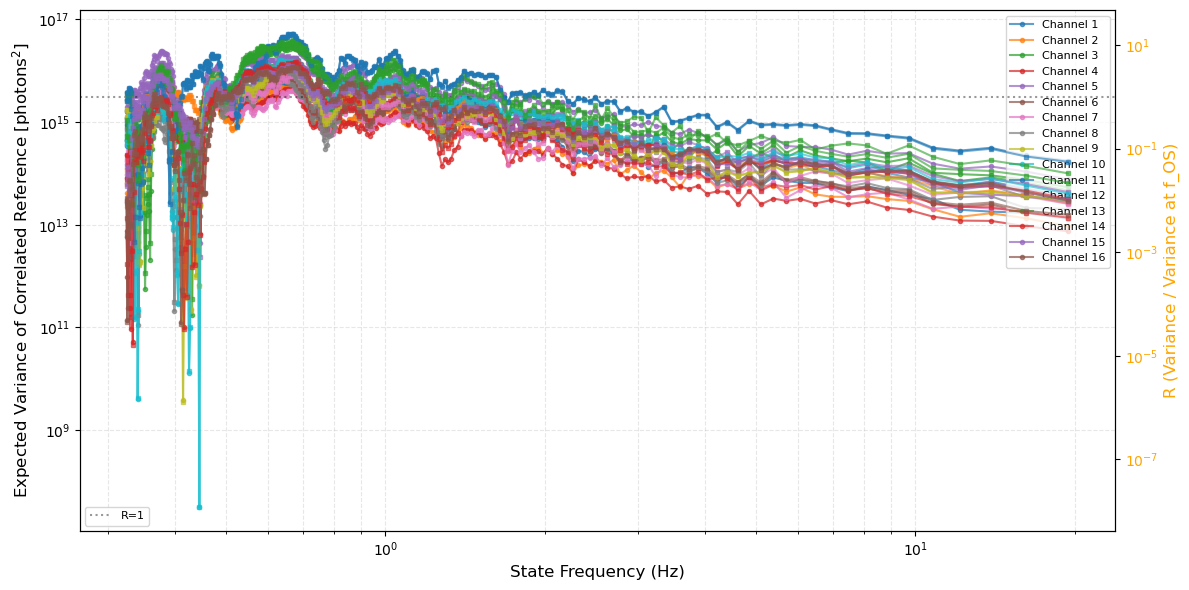

In [41]:
# Initialize array to store the expected variance of the correlated reference for each channel and state frequency
expected_var_corr_ref_all = np.zeros_like(R_factor)

fig, ax1 = plt.subplots(figsize=(12, 6))

for channel in range(result["channels"].shape[0]):
    expected_var_corr_ref = var_corr_ref[channel] * R_factor[channel, :]
    expected_var_corr_ref_all[channel, :] = expected_var_corr_ref
    ax1.plot(f_state, expected_var_corr_ref, marker='o', markersize=3, alpha=0.7, label=f'Channel {channel+1}')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('State Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Expected Variance of Correlated Reference [photons$^2$]', fontsize=12)
#ax1.set_title('Expected Variance of Correlated Reference vs State Frequency', fontsize=13)
ax1.grid(True, which="both", ls="--", alpha=0.3)
ax1.legend(loc='upper right', fontsize=8)

# Create secondary y-axis for R values (all channels)
ax2 = ax1.twinx()
# Add faint R=1 reference line underneath everything
ax2.axhline(1, color='black', linestyle=':', linewidth=1.5, alpha=0.4, zorder=1, label='R=1')
for channel in range(result["channels"].shape[0]):
    ax2.plot(f_state, R_factor[channel, :], marker='s', markersize=3, 
             linewidth=1.5, alpha=0.6, zorder=10)
ax2.set_yscale('log')
ax2.set_ylabel('R (Variance / Variance at f_OS)', fontsize=12, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

### Error Propagation for Expected Correlated Variance

For the product $\sigma^2_{corr}(f_c) = \sigma^2_{corr,ref} \times R(f_c)$, we need to propagate errors:

$$\frac{\delta(\sigma^2_{corr})}{\sigma^2_{corr}} = \sqrt{\left(\frac{\delta(\sigma^2_{corr,ref})}{\sigma^2_{corr,ref}}\right)^2 + \left(\frac{\delta R}{R}\right)^2}$$

For `var_corr_ref`, we can estimate its error from the standard error of the mean of `stack_variances`.

In [42]:
# Compute errors on var_corr_ref from channel_var_del_errors
# var_corr_ref = ((sky_photons_per_pixel_per_second / f_OS)**2) * channel_var_del
var_corr_ref_errors = ((sky_photons_per_pixel_per_second / f_OS)**2) * channel_var_del_errors

# Compute errors on expected_var_corr_ref_all using product error propagation
# For z = x * y, the error is: delta_z = z * sqrt((delta_x/x)^2 + (delta_y/y)^2)

expected_var_corr_ref_all_errors = np.zeros_like(expected_var_corr_ref_all)

for channel in range(result["channels"].shape[0]):
    for i in range(len(f_state)):
        var_ref = var_corr_ref[channel]
        var_ref_err = var_corr_ref_errors[channel]
        R = R_factor[channel, i]
        R_err = R_factor_errors[channel, i]
        
        if np.isfinite(R) and np.isfinite(var_ref) and np.isfinite(R_err) and np.isfinite(var_ref_err) and var_ref > 0 and R > 0:
            # Product error propagation
            relative_error = np.sqrt((var_ref_err / var_ref)**2 + (R_err / R)**2)
            expected_var_corr_ref_all_errors[channel, i] = expected_var_corr_ref_all[channel, i] * relative_error
        else:
            expected_var_corr_ref_all_errors[channel, i] = np.nan

print(f"Errors computed for expected correlated variance: {np.sum(np.isfinite(expected_var_corr_ref_all_errors))} valid points")

Errors computed for expected correlated variance: 4425 valid points


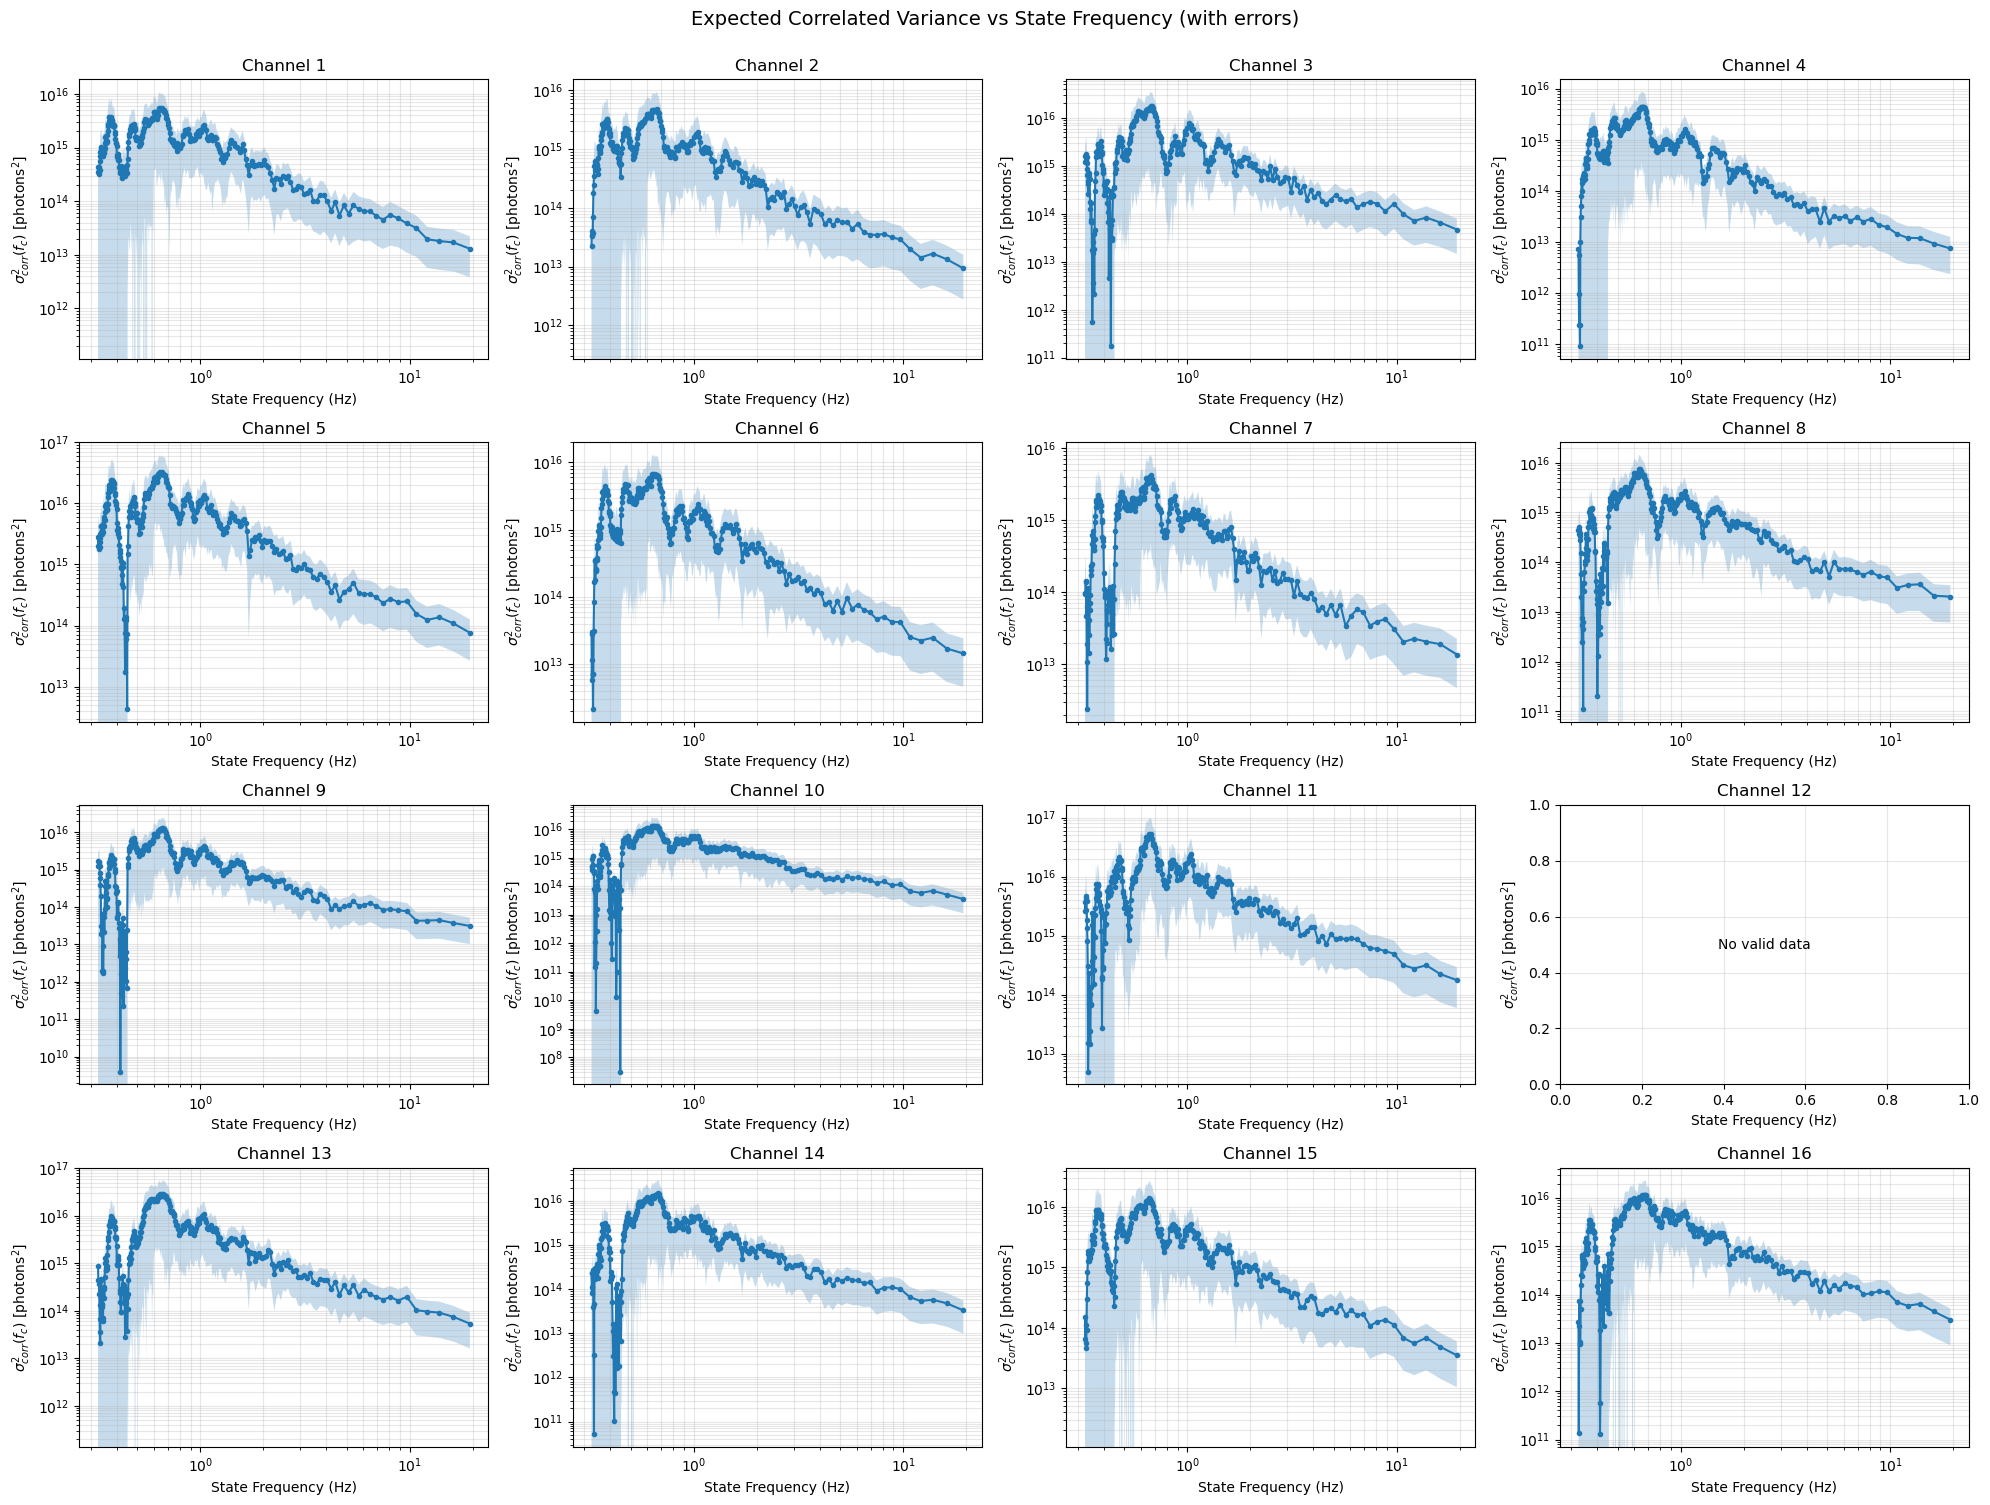

In [43]:
# Plot expected correlated variance with errors (all channels with shaded regions)
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
f_state_array = np.array(f_state)

for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    
    var_values = expected_var_corr_ref_all[channel, :]
    var_errors = expected_var_corr_ref_all_errors[channel, :]
    
    # Filter out non-positive values for log scale
    good = (np.isfinite(var_values) & (var_values > 0) & 
            np.isfinite(var_errors) & np.isfinite(f_state_array))
    
    if np.any(good):
        ax.plot(f_state_array[good], var_values[good], linewidth=1.5, 
                marker='o', markersize=3, label=f'Channel {channel+1}')
        ax.fill_between(f_state_array[good], 
                        (var_values - var_errors)[good], 
                        (var_values + var_errors)[good], 
                        alpha=0.25)
        ax.set_xscale('log')
        ax.set_yscale('log')
    else:
        ax.text(0.5, 0.5, "No valid data", ha='center', va='center', 
                transform=ax.transAxes)
    
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel(r'$\sigma^2_{corr}(f_c)$ [photons$^2$]')
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Expected Correlated Variance vs State Frequency (with errors)', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Signal for asteriod 

From looking at the plots, it seems like the flux throughout N-band (8.5 -13 microns)

### Load the filter data

[ 77475.     77764.472  78053.945  78343.417  78632.889  78922.362
  79211.834  79501.307  79790.779  80080.251  80369.724  80659.196
  80948.668  81238.141  81527.613  81817.085  82106.558  82396.03
  82685.503  82974.975  83264.447  83553.92   83843.392  84132.864
  84422.337  84711.809  85001.281  85290.754  85580.226  85869.698
  86159.171  86448.643  86738.116  87027.588  87317.06   87606.533
  87896.005  88185.477  88474.95   88764.422  89053.894  89343.367
  89632.839  89922.312  90211.784  90501.256  90790.729  91080.201
  91369.673  91659.146  91948.618  92238.09   92527.563  92817.035
  93106.508  93395.98   93685.452  93974.925  94264.397  94553.869
  94843.342  95132.814  95422.286  95711.759  96001.231  96290.704
  96580.176  96869.648  97159.121  97448.593  97738.065  98027.538
  98317.01   98606.482  98895.955  99185.427  99474.899  99764.372
 100053.84  100343.32  100632.79  100922.26  101211.73  101501.21
 101790.68  102080.15  102369.62  102659.1   102948.57  103238.0

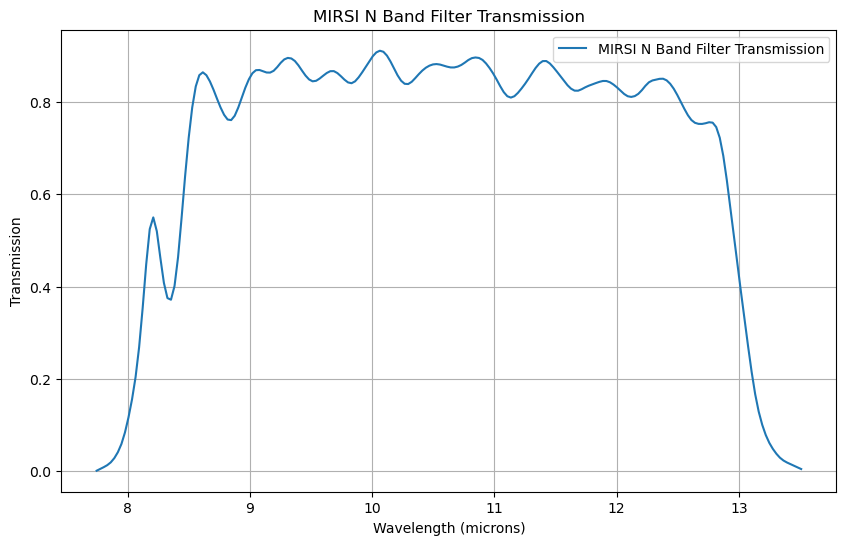

In [44]:
# First read in the filter transmission curve from the file
# load the filter profile from the .dat file 
filter_wl, filter_trans = np.genfromtxt('IRTF_MIRSI.N.dat', unpack=True)
#%%
print(filter_wl)
#%% 
# Convert filter wl from angstroms to nm 
filter_wl_microns = filter_wl / 10000.0  # angstroms to microns

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, filter_trans, label='MIRSI N Band Filter Transmission')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Transmission')
plt.title('MIRSI N Band Filter Transmission')
plt.legend()
plt.grid(True)
plt.show()

Make a fudicial plot which is a tophat function with the value of 8.5e-13 W m^-2 micron^-1 over the N Band (same wavelength range as the filter) and zero elsewhere. Convert this to photons/s/m^2/micron and plot it on the same plot as the filter transmission curve. This is just a rough estimate of the expected flux in the N band for a bright source, but it will allow us to visualize how the expected flux compares to the filter transmission.

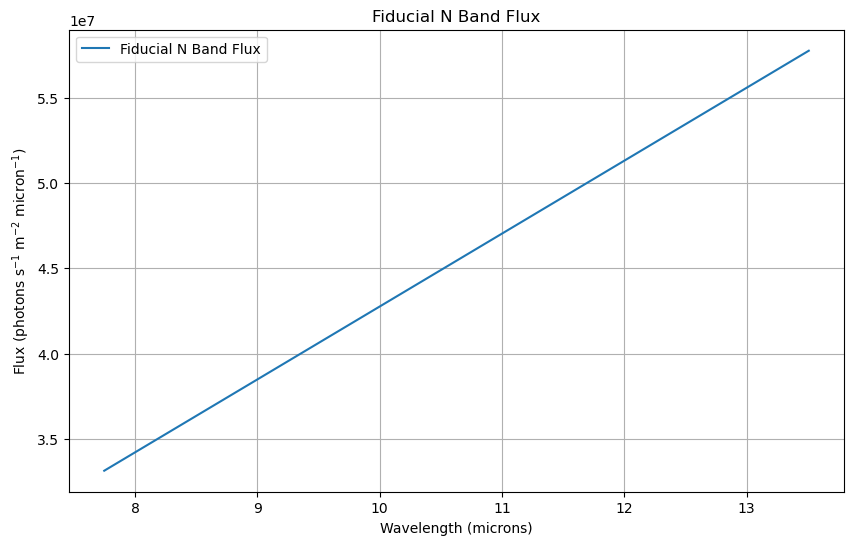

In [45]:

n_band_flux = np.full_like(filter_wl_microns, 8.5e-13)  # W m^-2 micron^-1
# Convert to photons/s/m^2/micron using the energy of the photons at that wavelength (E = hc/lambda)
h = 6.626e-34  # Planck's constant in J*s
c = 3e8  # Speed of light in m/s
n_band_flux_photons = n_band_flux * (filter_wl_microns * 1e-6) / (h * c)  # photons/s/m^2/micron
plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, n_band_flux_photons, label='Fiducial N Band Flux')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (photons s$^{-1}$ m$^{-2}$ micron$^{-1}$)')
plt.title('Fiducial N Band Flux')
plt.legend()
plt.grid(True)
plt.show()

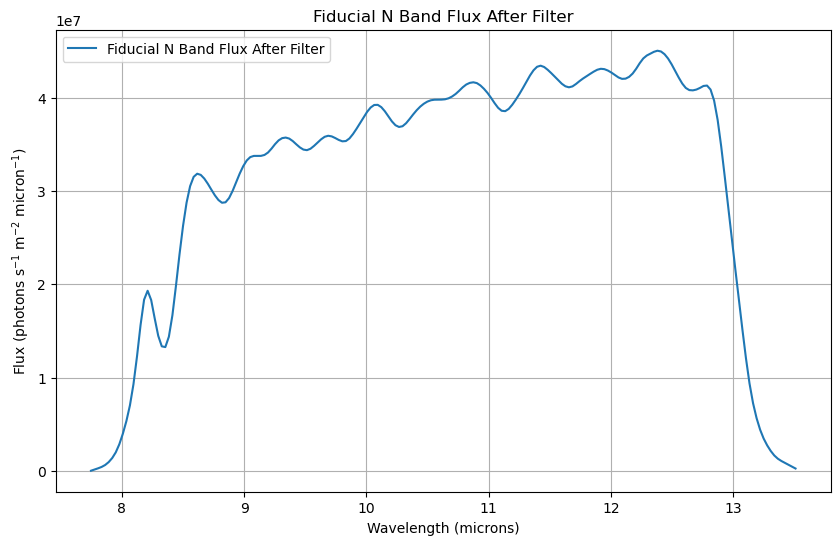

In [46]:
# Now multiply the fiducial N band flux by the filter transmission to get the expected flux after the filter - they're the same shape so just multiply elementwise
n_band_flux_after_filter = n_band_flux_photons * filter_trans

plt.figure(figsize=(10, 6))
plt.plot(filter_wl_microns, n_band_flux_after_filter, label='Fiducial N Band Flux After Filter')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (photons s$^{-1}$ m$^{-2}$ micron$^{-1}$)')
plt.title('Fiducial N Band Flux After Filter')
plt.legend()
plt.grid(True)
plt.show()

The shape makes sense - for the same flux, you expect less photons (more energetic). Convert this to a photon rate by integrating over the wavelength range of the filter and multiplying by the collecting area of the telescope and the solid angle of a pixel to get the expected photon rate in a pixel from this fiducial source after the filter. This will allow us to compare it to the sky background photon rate we calculated earlier.

Convert this to a photon rate by integrating over the wavelength range of the filter and multiplying by the collecting area of the telescope and the solid angle of a pixel to get the expected photon rate in a pixel from this fiducial source after the filter. This will allow us to compare it to the sky background photon rate we calculated earlier.
First integrate the flux after the filter over the wavelength range of the filter to get the total flux in photons/s/m^2


In [47]:
integrated_flux_asteroid = simpson(n_band_flux_after_filter, filter_wl_microns)  # photons/s/m^2

In [48]:
print(f"Integrated flux of the fiducial source after the filter: {integrated_flux_asteroid:.3e} ph/s/m^2")

Integrated flux of the fiducial source after the filter: 1.830e+08 ph/s/m^2


From the paper, the In this case, the aperture is 6 arcseconds. (what I assume is a diameter). this corresponds to an area of SA = pi*(3**2) arcseconds. The number of pixels in that is then SA/omega_pix.

In [49]:
SA = np.pi * (3**2) # solid angle in arcsec^2 of a 3 arcsec radius aperture

n_pixels = SA / omega_pix  # number of pixels in the aperture

print(f"Number of pixels in a 3 arcsec radius aperture: {n_pixels:.2f}")
print(f"which is about {np.sqrt(n_pixels):.2f} x {np.sqrt(n_pixels):.2f} pixels")

Number of pixels in a 3 arcsec radius aperture: 387.85
which is about 19.69 x 19.69 pixels


In [50]:
# We know that the collecting area of the telescope is A_tel and the solid angle of a pixel is omega_pix, so we can multiply the integrated flux by these to get the expected photon rate in a pixel from this fiducial source on the detector
expected_photon_rate_asteroid = integrated_flux_asteroid * A_tel * eta_tel * QE / n_pixels
print(f"Expected photon rate in a pixel from the fiducial source on detector: {expected_photon_rate_asteroid:.3e} ph/s/pixel)")

Expected photon rate in a pixel from the fiducial source on detector: 7.033e+05 ph/s/pixel)


# Compute SNR 

In [51]:
# Compute SNR for all channels at once
def signal_to_noise_all_channels(source_rate, sky_rate, t_int, f_state):
    """
    Compute SNR for all channels.
    
    Returns:
        snr_all: array of shape (n_channels, n_frequencies)
    """
    n_channels = expected_var_corr_ref_all.shape[0]
    n_freq = len(f_state)
    
    # Reverse variance array to match reversed f_state
    var_corr_per_sample = expected_var_corr_ref_all[:, ::-1]  # shape: (n_channels, n_freq)
    
    # N_samples is same for all channels
    N_samples = t_int * np.asarray(f_state)
    N_samples_rounded = np.maximum(N_samples, 1)  # Avoid division by less than 1
    
    # Broadcast to work with all channels
    var_corr_total = var_corr_per_sample / N_samples_rounded[np.newaxis, :]  # shape: (n_channels, n_freq)
    
    # Poisson variance (same for all channels)
    var_poisson = (source_rate + sky_rate) * t_int
    
    # SNR for all channels
    snr_all = (source_rate * t_int) / (np.sqrt(2) * np.sqrt(var_poisson + var_corr_total))
    
    return snr_all

In [52]:
# Compute SNR for all channels
t_int = 0.0103
snr_all_channels = signal_to_noise_all_channels(
    expected_photon_rate_asteroid, 
    sky_photons_per_pixel_per_second, 
    t_int, 
    f_state=f_state[::-1]
)

print(f"SNR array shape: {snr_all_channels.shape}")
print(f"Channels: {snr_all_channels.shape[0]}, Frequencies: {snr_all_channels.shape[1]}")

SNR array shape: (16, 295)
Channels: 16, Frequencies: 295


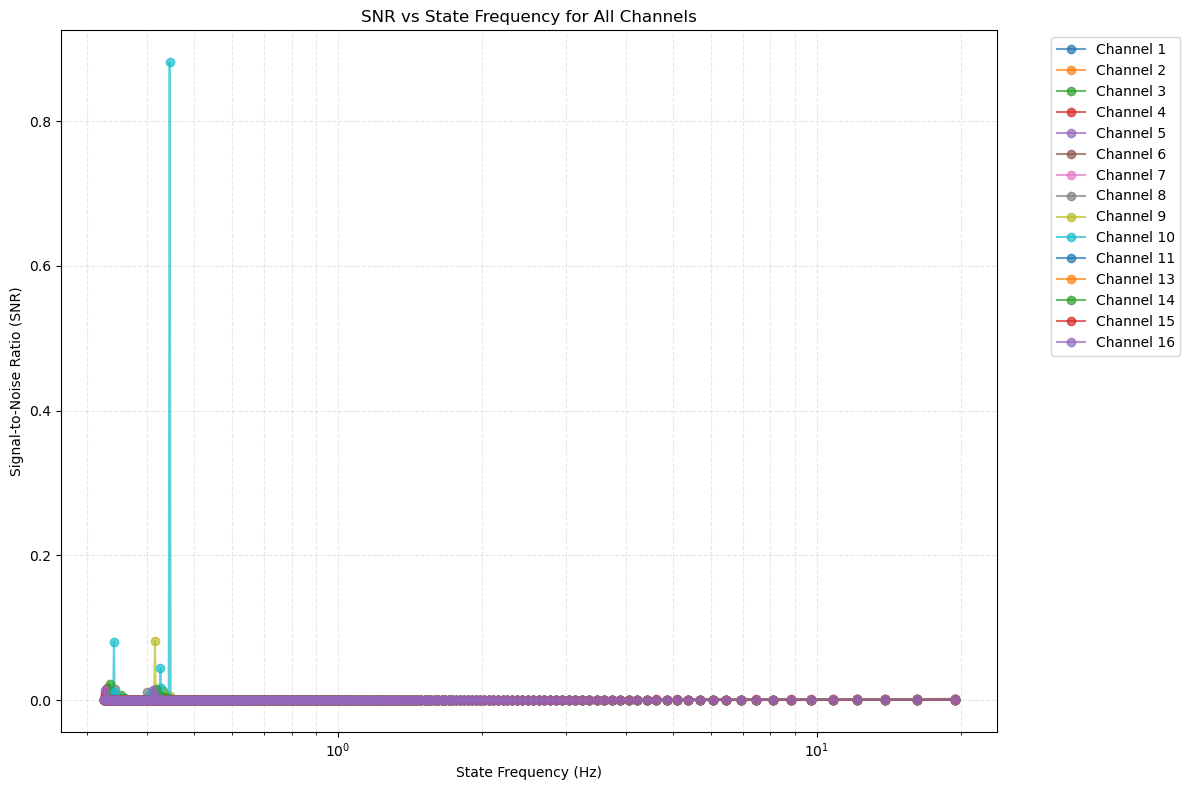

In [53]:
plt.figure(figsize=(12, 8))
for channel in range(snr_all_channels.shape[0]):
    if channel == 11:  # Skip bad channel
        continue
    plt.plot(f_state[::-1], snr_all_channels[channel, :], 
             marker='o', alpha=0.7, label=f'Channel {channel+1}')

plt.xscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.title('SNR vs State Frequency for All Channels')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# Compute relative improvement for all channels
f_OS = 0.5
snr_at_f_OS_all = np.zeros(snr_all_channels.shape[0])
max_improvement_all = np.zeros(snr_all_channels.shape[0])

for channel in range(snr_all_channels.shape[0]):
    # Interpolate SNR at f_OS
    snr_at_f_OS_all[channel] = np.interp(f_OS, f_state[::-1], snr_all_channels[channel, :])
    
    # Find max improvement where f < 10 Hz
    mask = np.array(f_state[::-1]) < 10
    relative_improvement = snr_all_channels[channel, :] / snr_at_f_OS_all[channel]
    max_improvement_all[channel] = np.max(relative_improvement[mask])

# Print results
print("Relative SNR Improvement by Channel (f < 10 Hz):")
print("=" * 50)
for channel in range(len(max_improvement_all)):
    if channel == 11:
        print(f"Channel {channel+1:2d}: SKIPPED (bad channel)")
    else:
        delta_m = 2.5 * np.log10(max_improvement_all[channel])
        print(f"Channel {channel+1:2d}: {max_improvement_all[channel]:5.2f}x  ({delta_m:+.2f} mag)")

print("=" * 50)
print(f"Mean improvement (excluding ch 12): {np.mean(np.delete(max_improvement_all, 11)):.2f}x")
print(f"Median improvement (excluding ch 12): {np.median(np.delete(max_improvement_all, 11)):.2f}x")

Relative SNR Improvement by Channel (f < 10 Hz):
Channel  1:  6.03x  (+1.95 mag)
Channel  2:  6.90x  (+2.10 mag)
Channel  3: 90.30x  (+4.89 mag)
Channel  4: 132.46x  (+5.31 mag)
Channel  5: 34.79x  (+3.85 mag)
Channel  6: 35.54x  (+3.88 mag)
Channel  7: 25.67x  (+3.52 mag)
Channel  8: 128.66x  (+5.27 mag)
Channel  9: 884.65x  (+7.37 mag)
Channel 10: 8845.45x  (+9.87 mag)
Channel 11: 25.12x  (+3.50 mag)
Channel 12: SKIPPED (bad channel)
Channel 13: 10.78x  (+2.58 mag)
Channel 14: 246.99x  (+5.98 mag)
Channel 15:  8.63x  (+2.34 mag)
Channel 16: 155.87x  (+5.48 mag)
Mean improvement (excluding ch 12): 709.19x
Median improvement (excluding ch 12): 35.54x


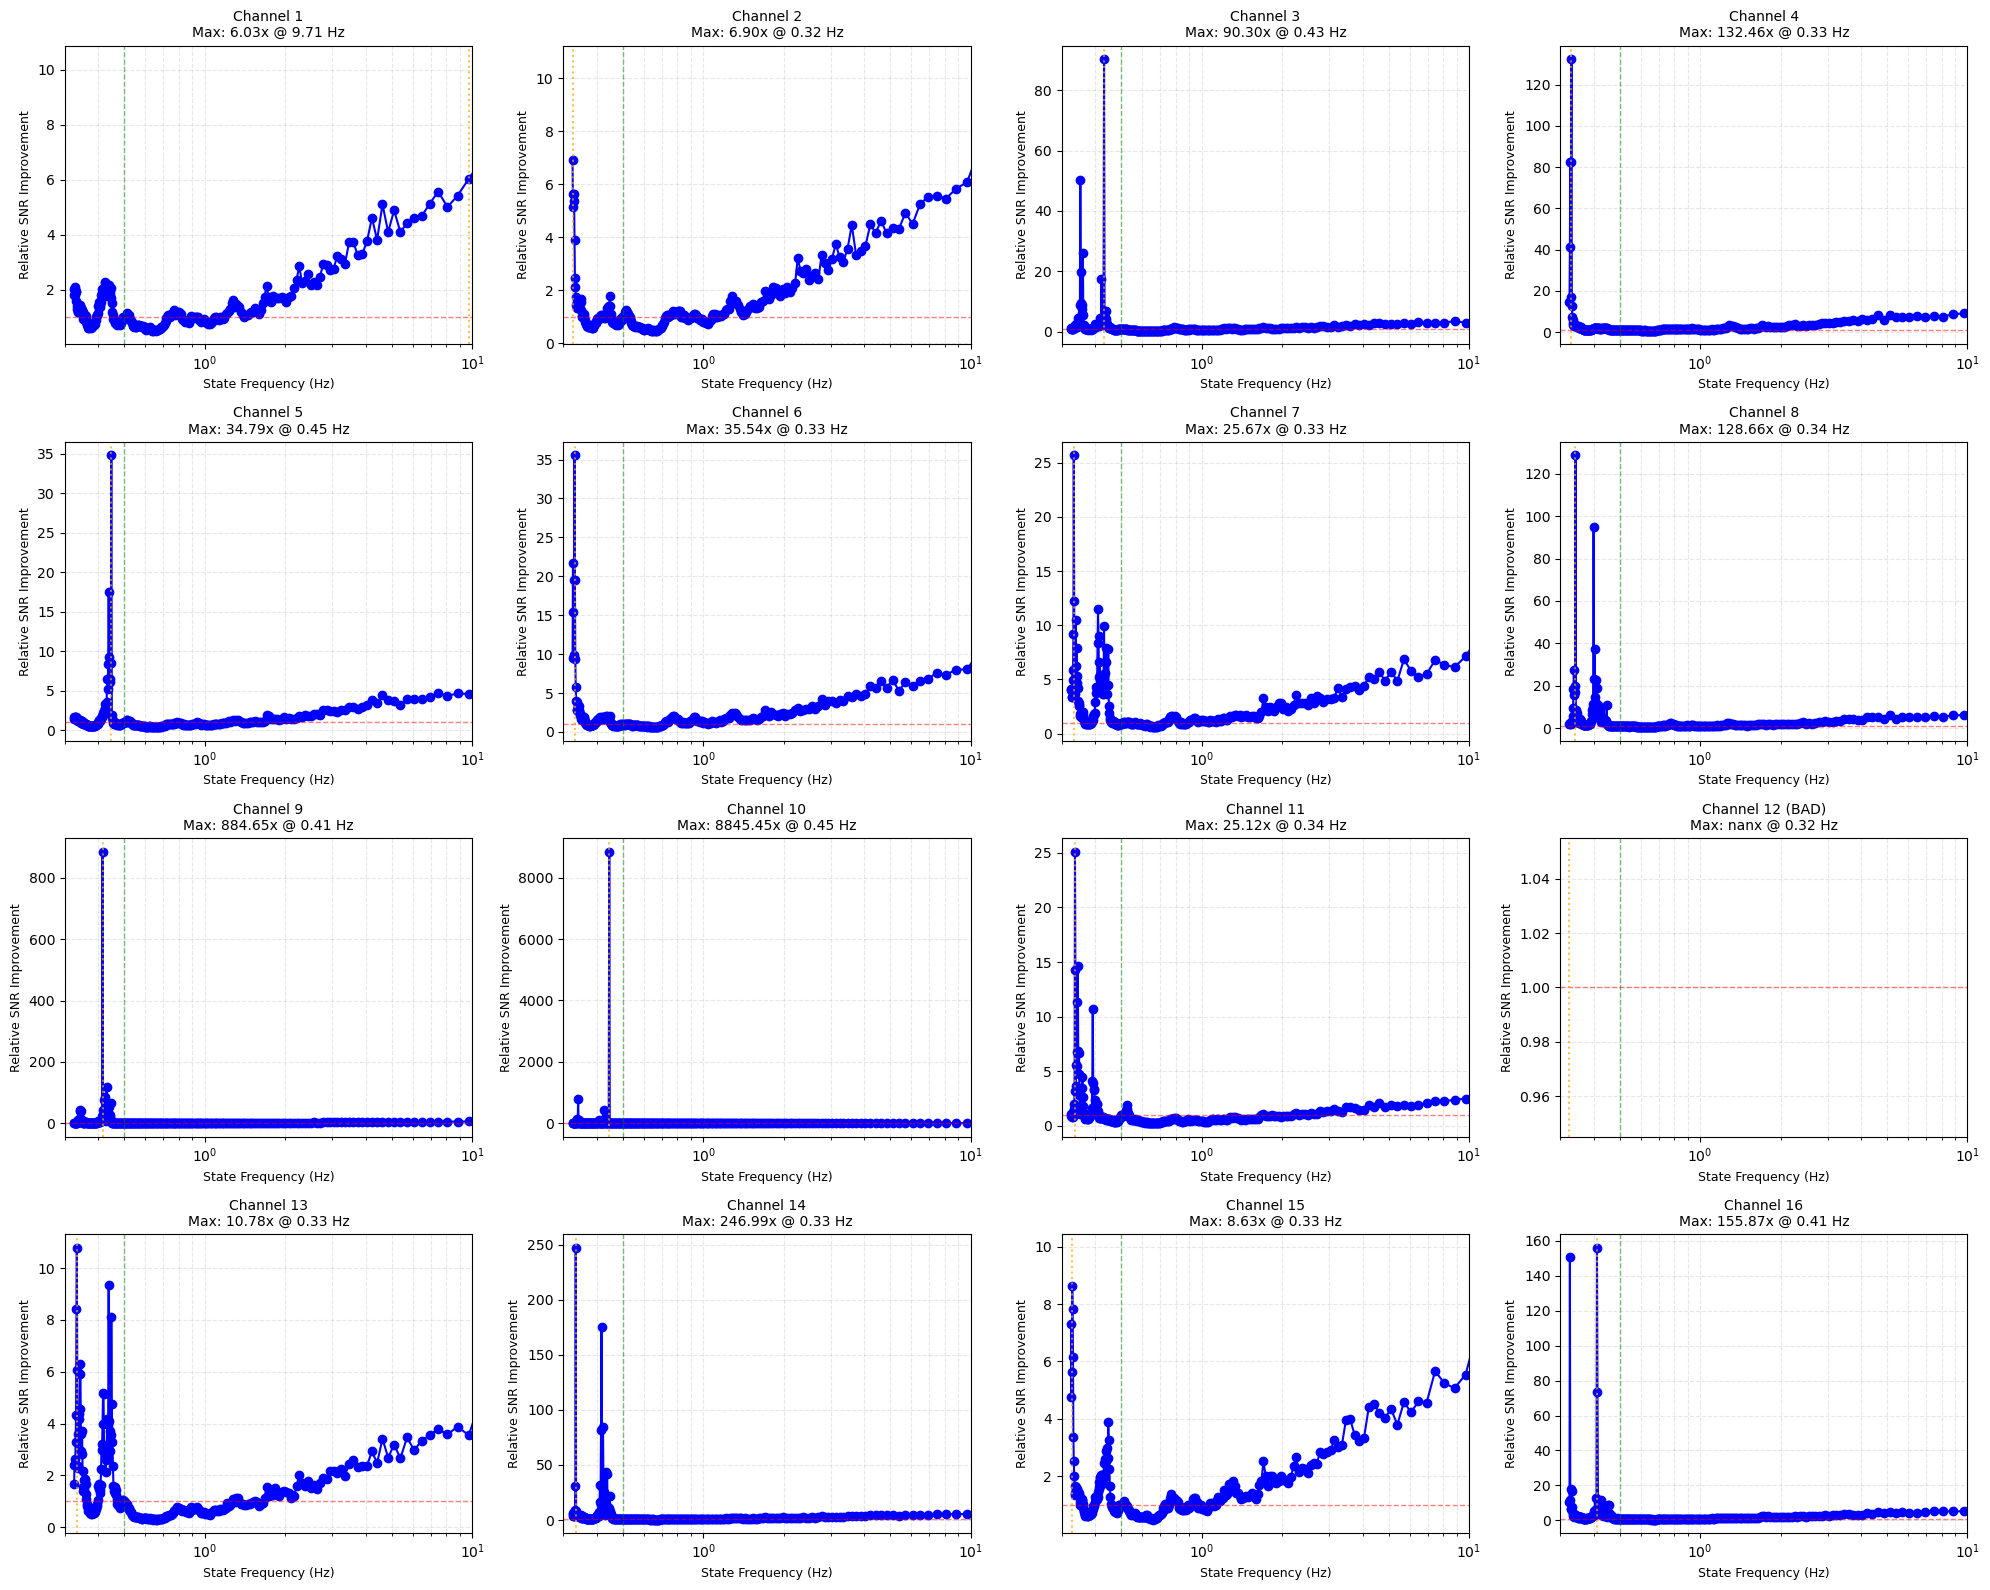

In [55]:
# Plot relative improvement for each channel in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for channel in range(snr_all_channels.shape[0]):
    ax = axes[channel // 4, channel % 4]
    
    relative_improvement = snr_all_channels[channel, :] / snr_at_f_OS_all[channel]
    
    ax.plot(f_state[::-1], relative_improvement, marker='o', color='blue')
    ax.axhline(1, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(f_OS, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    # Highlight max improvement
    mask = np.array(f_state[::-1]) < 10
    max_idx = np.argmax(relative_improvement[mask])
    f_at_max = np.array(f_state[::-1])[mask][max_idx]
    ax.axvline(f_at_max, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    
    ax.set_xscale('log')
    ax.set_xlim(3e-1, 1e1)
    ax.set_xlabel('State Frequency (Hz)', fontsize=9)
    ax.set_ylabel('Relative SNR Improvement', fontsize=9)
    
    title_str = f'Channel {channel+1}'
    if channel == 11:
        title_str += ' (BAD)'
    title_str += f'\nMax: {max_improvement_all[channel]:.2f}x @ {f_at_max:.2f} Hz'
    ax.set_title(title_str, fontsize=10)
    
    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Great now plot it with error bars


In [56]:
def signal_to_noise_with_error(source_rate, sky_rate, t_int, channel, f_state_input,
                               sigma_source=None, sigma_sky=None, sigma_var_corr=None):
    """
    Compute signal-to-noise ratio with error propagation.
    
    Parameters
    ----------
    source_rate : float
        Source photon rate (ph/s/pixel)
    sky_rate : float
        Sky background photon rate (ph/s/pixel)
    t_int : float
        Integration time per frame (s)
    channel : int
        Channel index (0-15)
    f_state_input : array
        State frequencies (can be in any order)
    sigma_source : float or None
        Uncertainty in source_rate. If None, assumes Poisson: sqrt(source_rate * t_int)
    sigma_sky : float or None
        Uncertainty in sky_rate. If None, assumes Poisson: sqrt(sky_rate * t_int)
    sigma_var_corr : array or None
        Uncertainty in correlated variance per sample. If None, assumes var_corr/sqrt(N_samples)
    
    Returns
    -------
    snr : array
        Signal-to-noise ratio at each f_state frequency
    sigma_snr : array
        Uncertainty in SNR at each frequency
    """
    # Get the expected variance - this is ALWAYS indexed in the original f_state order
    var_corr_per_sample_original = expected_var_corr_ref_all[channel, :]
    
    # Create a mapping: we need to match f_state_input with the original f_state order
    f_state_input_array = np.asarray(f_state_input)
    
    # Create variance array in the same order as f_state_input
    var_corr_per_sample = np.zeros_like(f_state_input_array)
    for i, f in enumerate(f_state_input_array):
        # Find the index in the original f_state that matches this frequency
        idx = np.argmin(np.abs(np.array(f_state) - f))
        var_corr_per_sample[i] = var_corr_per_sample_original[idx]
    
    # Compute N_samples at each frequency
    N_samples = t_int * f_state_input_array
    N_samples_rounded = np.maximum(N_samples, 1)
    
    # Total variance
    var_corr_total = var_corr_per_sample / N_samples_rounded
    var_poisson = (source_rate + sky_rate) * t_int
    total_var = var_poisson + var_corr_total
    
    # SNR calculation
    snr = (source_rate * t_int) / (np.sqrt(2) * np.sqrt(total_var))
    
    # --- Error Propagation ---
    # Using logarithmic differentiation for cleaner derivatives:
    # d(ln SNR)/dS = 1/S - t_int/(2*V)
    # d(ln SNR)/dB = -t_int/(2*V)
    # d(ln SNR)/d(var_corr) = -1/(2*V*N_samples)
    
    # Set default uncertainties if not provided
    if sigma_source is None:
        # Poisson uncertainty in total source counts
        sigma_source = np.sqrt(source_rate * t_int) / t_int
    
    if sigma_sky is None:
        # Poisson uncertainty in total sky counts
        sigma_sky = np.sqrt(sky_rate * t_int) / t_int
    
    if sigma_var_corr is None:
        # Uncertainty in variance estimate scales as variance / sqrt(N_samples)
        sigma_var_corr = var_corr_per_sample / np.sqrt(N_samples_rounded)
    
    # Partial derivatives (using chain rule)
    dSNR_dS = snr * (1.0/source_rate - t_int/(2*total_var))
    dSNR_dB = snr * (-t_int/(2*total_var))
    dSNR_dvar_corr = snr * (-1.0/(2*total_var*N_samples_rounded))
    
    # Error propagation: sigma_SNR^2 = sum of (partial_derivative * sigma)^2
    sigma_snr_sq = (dSNR_dS * sigma_source)**2 + \
                   (dSNR_dB * sigma_sky)**2 + \
                   (dSNR_dvar_corr * sigma_var_corr)**2
    
    sigma_snr = np.sqrt(sigma_snr_sq)
    
    return snr, sigma_snr

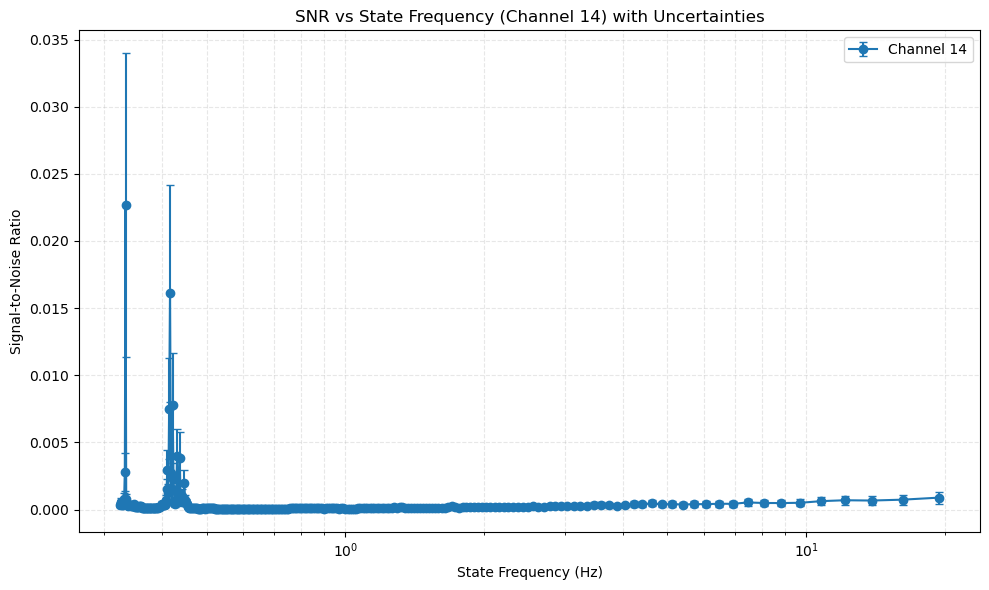

In [57]:
# Example usage with error propagation
channel_test = 13

# Compute SNR with uncertainties
snr_with_err, sigma_snr = signal_to_noise_with_error(
    expected_photon_rate_asteroid, 
    sky_photons_per_pixel_per_second, 
    t_int, 
    channel=channel_test, 
    f_state_input=f_state[::-1]
)

# Plot with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(f_state[::-1], snr_with_err, yerr=sigma_snr, 
             marker='o', capsize=3, label=f'Channel {channel_test+1}')
plt.xscale('log')
plt.xlabel('State Frequency (Hz)')
plt.ylabel('Signal-to-Noise Ratio')
plt.title(f'SNR vs State Frequency (Channel {channel_test+1}) with Uncertainties')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
def signal_to_noise_all_channels_with_error(source_rate, sky_rate, t_int, f_state,
                                            sigma_source=None, sigma_sky=None, sigma_var_corr=None):
    """
    Compute SNR with error propagation for all channels.
    
    Parameters
    ----------
    source_rate : float
        Source photon rate (ph/s/pixel)
    sky_rate : float
        Sky background photon rate (ph/s/pixel)
    t_int : float
        Integration time per frame (s)
    f_state : array
        State frequencies
    sigma_source : float or None
        Uncertainty in source_rate. If None, assumes Poisson: sqrt(source_rate * t_int)
    sigma_sky : float or None
        Uncertainty in sky_rate. If None, assumes Poisson: sqrt(sky_rate * t_int)
    sigma_var_corr : array or None
        Uncertainty in correlated variance per sample (n_channels, n_freq). 
        If None, assumes var_corr/sqrt(N_samples)
    
    Returns
    -------
    snr_all : array (n_channels, n_frequencies)
        Signal-to-noise ratio for all channels at each f_state frequency
    sigma_snr_all : array (n_channels, n_frequencies)
        Uncertainty in SNR for all channels at each frequency
    """
    n_channels = expected_var_corr_ref_all.shape[0]
    n_freq = len(f_state)
    
    # Reverse variance array to match reversed f_state
    var_corr_per_sample = expected_var_corr_ref_all[:, ::-1]  # shape: (n_channels, n_freq)
    
    # N_samples is same for all channels
    N_samples = t_int * np.asarray(f_state)
    N_samples_rounded = np.maximum(N_samples, 1)  # Avoid division by less than 1
    
    # Broadcast to work with all channels
    var_corr_total = var_corr_per_sample / N_samples_rounded[np.newaxis, :]  # shape: (n_channels, n_freq)
    
    # Poisson variance (same for all channels)
    var_poisson = (source_rate + sky_rate) * t_int
    total_var = var_poisson + var_corr_total
    
    # SNR for all channels
    snr_all = (source_rate * t_int) / (np.sqrt(2) * np.sqrt(total_var))
    
    # --- Error Propagation ---
    # Set default uncertainties if not provided
    if sigma_source is None:
        sigma_source = np.sqrt(source_rate * t_int) / t_int
    
    if sigma_sky is None:
        sigma_sky = np.sqrt(sky_rate * t_int) / t_int
    
    if sigma_var_corr is None:
        # Uncertainty in variance estimate scales as variance / sqrt(N_samples)
        sigma_var_corr = var_corr_per_sample / np.sqrt(N_samples_rounded[np.newaxis, :])
    
    # Partial derivatives
    dSNR_dS = snr_all * (1.0/source_rate - t_int/(2*total_var))
    dSNR_dB = snr_all * (-t_int/(2*total_var))
    dSNR_dvar_corr = snr_all * (-1.0/(2*total_var*N_samples_rounded[np.newaxis, :]))
    
    # Error propagation
    sigma_snr_sq = (dSNR_dS * sigma_source)**2 + \
                   (dSNR_dB * sigma_sky)**2 + \
                   (dSNR_dvar_corr * sigma_var_corr)**2
    
    sigma_snr_all = np.sqrt(sigma_snr_sq)
    
    return snr_all, sigma_snr_all

In [59]:
# Compute SNR with errors for all channels
snr_all, sigma_snr_all = signal_to_noise_all_channels_with_error(
    expected_photon_rate_asteroid, 
    sky_photons_per_pixel_per_second, 
    t_int=0.0103, 
    f_state=f_state[::-1]
)

print(f"SNR array shape: {snr_all.shape}")
print(f"Uncertainty array shape: {sigma_snr_all.shape}")
print(f"\nRelative uncertainty stats (all channels):")
rel_uncert = sigma_snr_all / snr_all
print(f"  Mean: {np.nanmean(rel_uncert)*100:.2f}%")
print(f"  Median: {np.nanmedian(rel_uncert)*100:.2f}%")
print(f"  Range: {np.nanmin(rel_uncert)*100:.2f}% - {np.nanmax(rel_uncert)*100:.2f}%")

SNR array shape: (16, 295)
Uncertainty array shape: (16, 295)

Relative uncertainty stats (all channels):
  Mean: 50.01%
  Median: 50.01%
  Range: 46.19% - 50.01%


/tmp/ipykernel_2060129/1880614953.py:21: RuntimeWarning: Mean of empty slice
  rel_unc_mean = np.nanmean(sigma_snr_all[channel, :] / snr_all[channel, :]) * 100


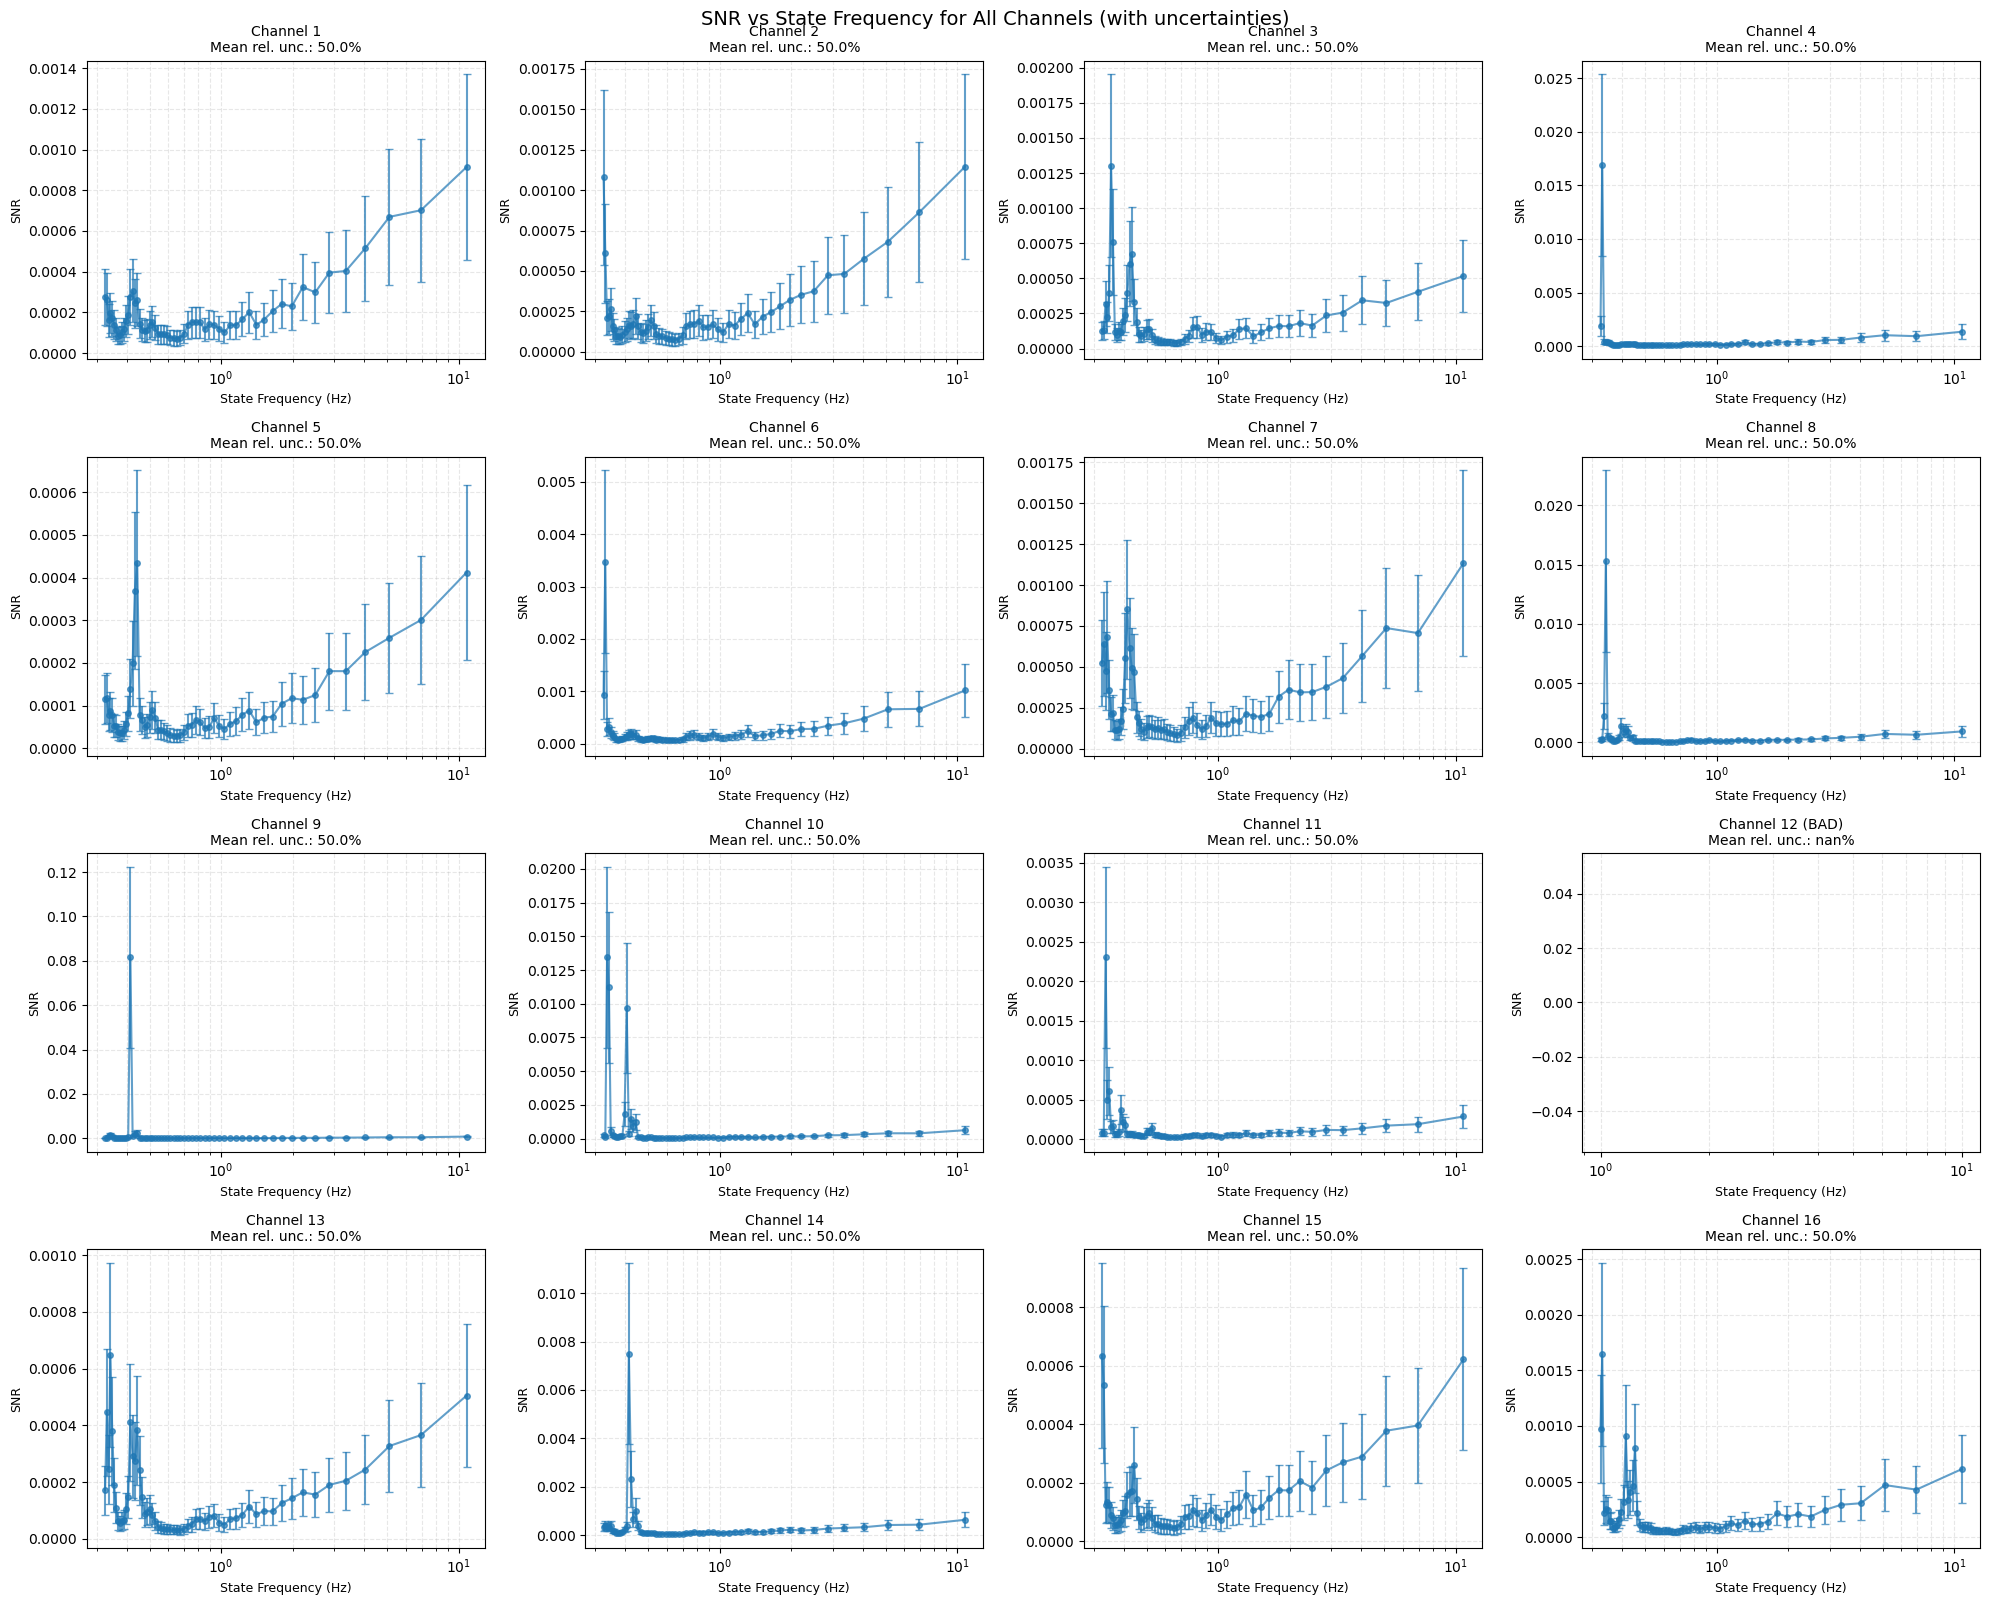

In [60]:
# Plot SNR with error bars for all channels
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for channel in range(snr_all.shape[0]):
    ax = axes[channel // 4, channel % 4]
    
    # Plot with error bars (but thin them out for readability - plot every 5th point)
    skip = 5
    ax.errorbar(f_state[::-1][::skip], snr_all[channel, ::skip], 
                yerr=sigma_snr_all[channel, ::skip],
                marker='o', capsize=3, alpha=0.7, markersize=4)
    
    ax.set_xscale('log')
    ax.set_xlabel('State Frequency (Hz)', fontsize=9)
    ax.set_ylabel('SNR', fontsize=9)
    
    title_str = f'Channel {channel+1}'
    if channel == 11:
        title_str += ' (BAD)'
    
    # Add relative uncertainty info
    rel_unc_mean = np.nanmean(sigma_snr_all[channel, :] / snr_all[channel, :]) * 100
    title_str += f'\nMean rel. unc.: {rel_unc_mean:.1f}%'
    ax.set_title(title_str, fontsize=10)
    
    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.suptitle('SNR vs State Frequency for All Channels (with uncertainties)', 
             fontsize=14, y=1.00)
plt.show()

In [61]:
# Compute improvement at specific frequency: 4 Hz
f_target = 4.0  # Hz
f_OS = 0.5

# Arrays to store results
snr_at_f_OS = np.zeros(snr_all.shape[0])
sigma_snr_at_f_OS = np.zeros(snr_all.shape[0])
snr_at_f_target = np.zeros(snr_all.shape[0])
sigma_snr_at_f_target = np.zeros(snr_all.shape[0])
improvement_at_4Hz = np.zeros(snr_all.shape[0])
sigma_improvement_at_4Hz = np.zeros(snr_all.shape[0])

for channel in range(snr_all.shape[0]):
    # Interpolate SNR and its uncertainty at f_OS
    snr_at_f_OS[channel] = np.interp(f_OS, f_state[::-1], snr_all[channel, :])
    sigma_snr_at_f_OS[channel] = np.interp(f_OS, f_state[::-1], sigma_snr_all[channel, :])
    
    # Interpolate SNR and its uncertainty at 4 Hz
    snr_at_f_target[channel] = np.interp(f_target, f_state[::-1], snr_all[channel, :])
    sigma_snr_at_f_target[channel] = np.interp(f_target, f_state[::-1], sigma_snr_all[channel, :])
    
    # Compute improvement: ratio = SNR(4 Hz) / SNR(f_OS)
    improvement_at_4Hz[channel] = snr_at_f_target[channel] / snr_at_f_OS[channel]
    
    # Error propagation for ratio
    sigma_improvement_at_4Hz[channel] = improvement_at_4Hz[channel] * np.sqrt(
        (sigma_snr_at_f_target[channel] / snr_at_f_target[channel])**2 +
        (sigma_snr_at_f_OS[channel] / snr_at_f_OS[channel])**2
    )

# Print results with uncertainties
print(f"SNR Improvement at {f_target} Hz (relative to {f_OS} Hz):")
print("=" * 60)
for channel in range(len(improvement_at_4Hz)):
    if channel == 11:
        print(f"Channel {channel+1:2d}: SKIPPED (bad channel)")
    else:
        delta_m = 2.5 * np.log10(improvement_at_4Hz[channel])
        # Error in magnitude: sigma_m = 2.5/ln(10) * sigma_ratio/ratio
        sigma_delta_m = 2.5 / np.log(10) * sigma_improvement_at_4Hz[channel] / improvement_at_4Hz[channel]
        print(f"Channel {channel+1:2d}: {improvement_at_4Hz[channel]:5.2f} ± {sigma_improvement_at_4Hz[channel]:4.2f}×  "
              f"({delta_m:+.2f} ± {sigma_delta_m:.2f} mag)")

print("=" * 60)
valid_mask = np.arange(len(improvement_at_4Hz)) != 11
print(f"Mean improvement at {f_target} Hz: {np.mean(improvement_at_4Hz[valid_mask]):.2f} ± {np.std(improvement_at_4Hz[valid_mask]):.2f}×")
print(f"Median improvement at {f_target} Hz: {np.median(improvement_at_4Hz[valid_mask]):.2f}×")

SNR Improvement at 4.0 Hz (relative to 0.5 Hz):
Channel  1:  3.63 ± 2.57×  (+1.40 ± 0.77 mag)
Channel  2:  3.63 ± 2.57×  (+1.40 ± 0.77 mag)
Channel  3:  2.42 ± 1.71×  (+0.96 ± 0.77 mag)
Channel  4:  6.05 ± 4.28×  (+1.95 ± 0.77 mag)
Channel  5:  3.10 ± 2.20×  (+1.23 ± 0.77 mag)
Channel  6:  4.83 ± 3.42×  (+1.71 ± 0.77 mag)
Channel  7:  4.31 ± 3.05×  (+1.59 ± 0.77 mag)
Channel  8:  3.98 ± 2.82×  (+1.50 ± 0.77 mag)
Channel  9:  4.21 ± 2.98×  (+1.56 ± 0.77 mag)
Channel 10:  3.14 ± 2.22×  (+1.24 ± 0.77 mag)
Channel 11:  1.50 ± 1.06×  (+0.44 ± 0.77 mag)
Channel 12: SKIPPED (bad channel)
Channel 13:  2.38 ± 1.68×  (+0.94 ± 0.77 mag)
Channel 14:  3.45 ± 2.44×  (+1.35 ± 0.77 mag)
Channel 15:  3.30 ± 2.34×  (+1.30 ± 0.77 mag)
Channel 16:  3.30 ± 2.33×  (+1.30 ± 0.77 mag)
Mean improvement at 4.0 Hz: 3.55 ± 1.05×
Median improvement at 4.0 Hz: 3.45×


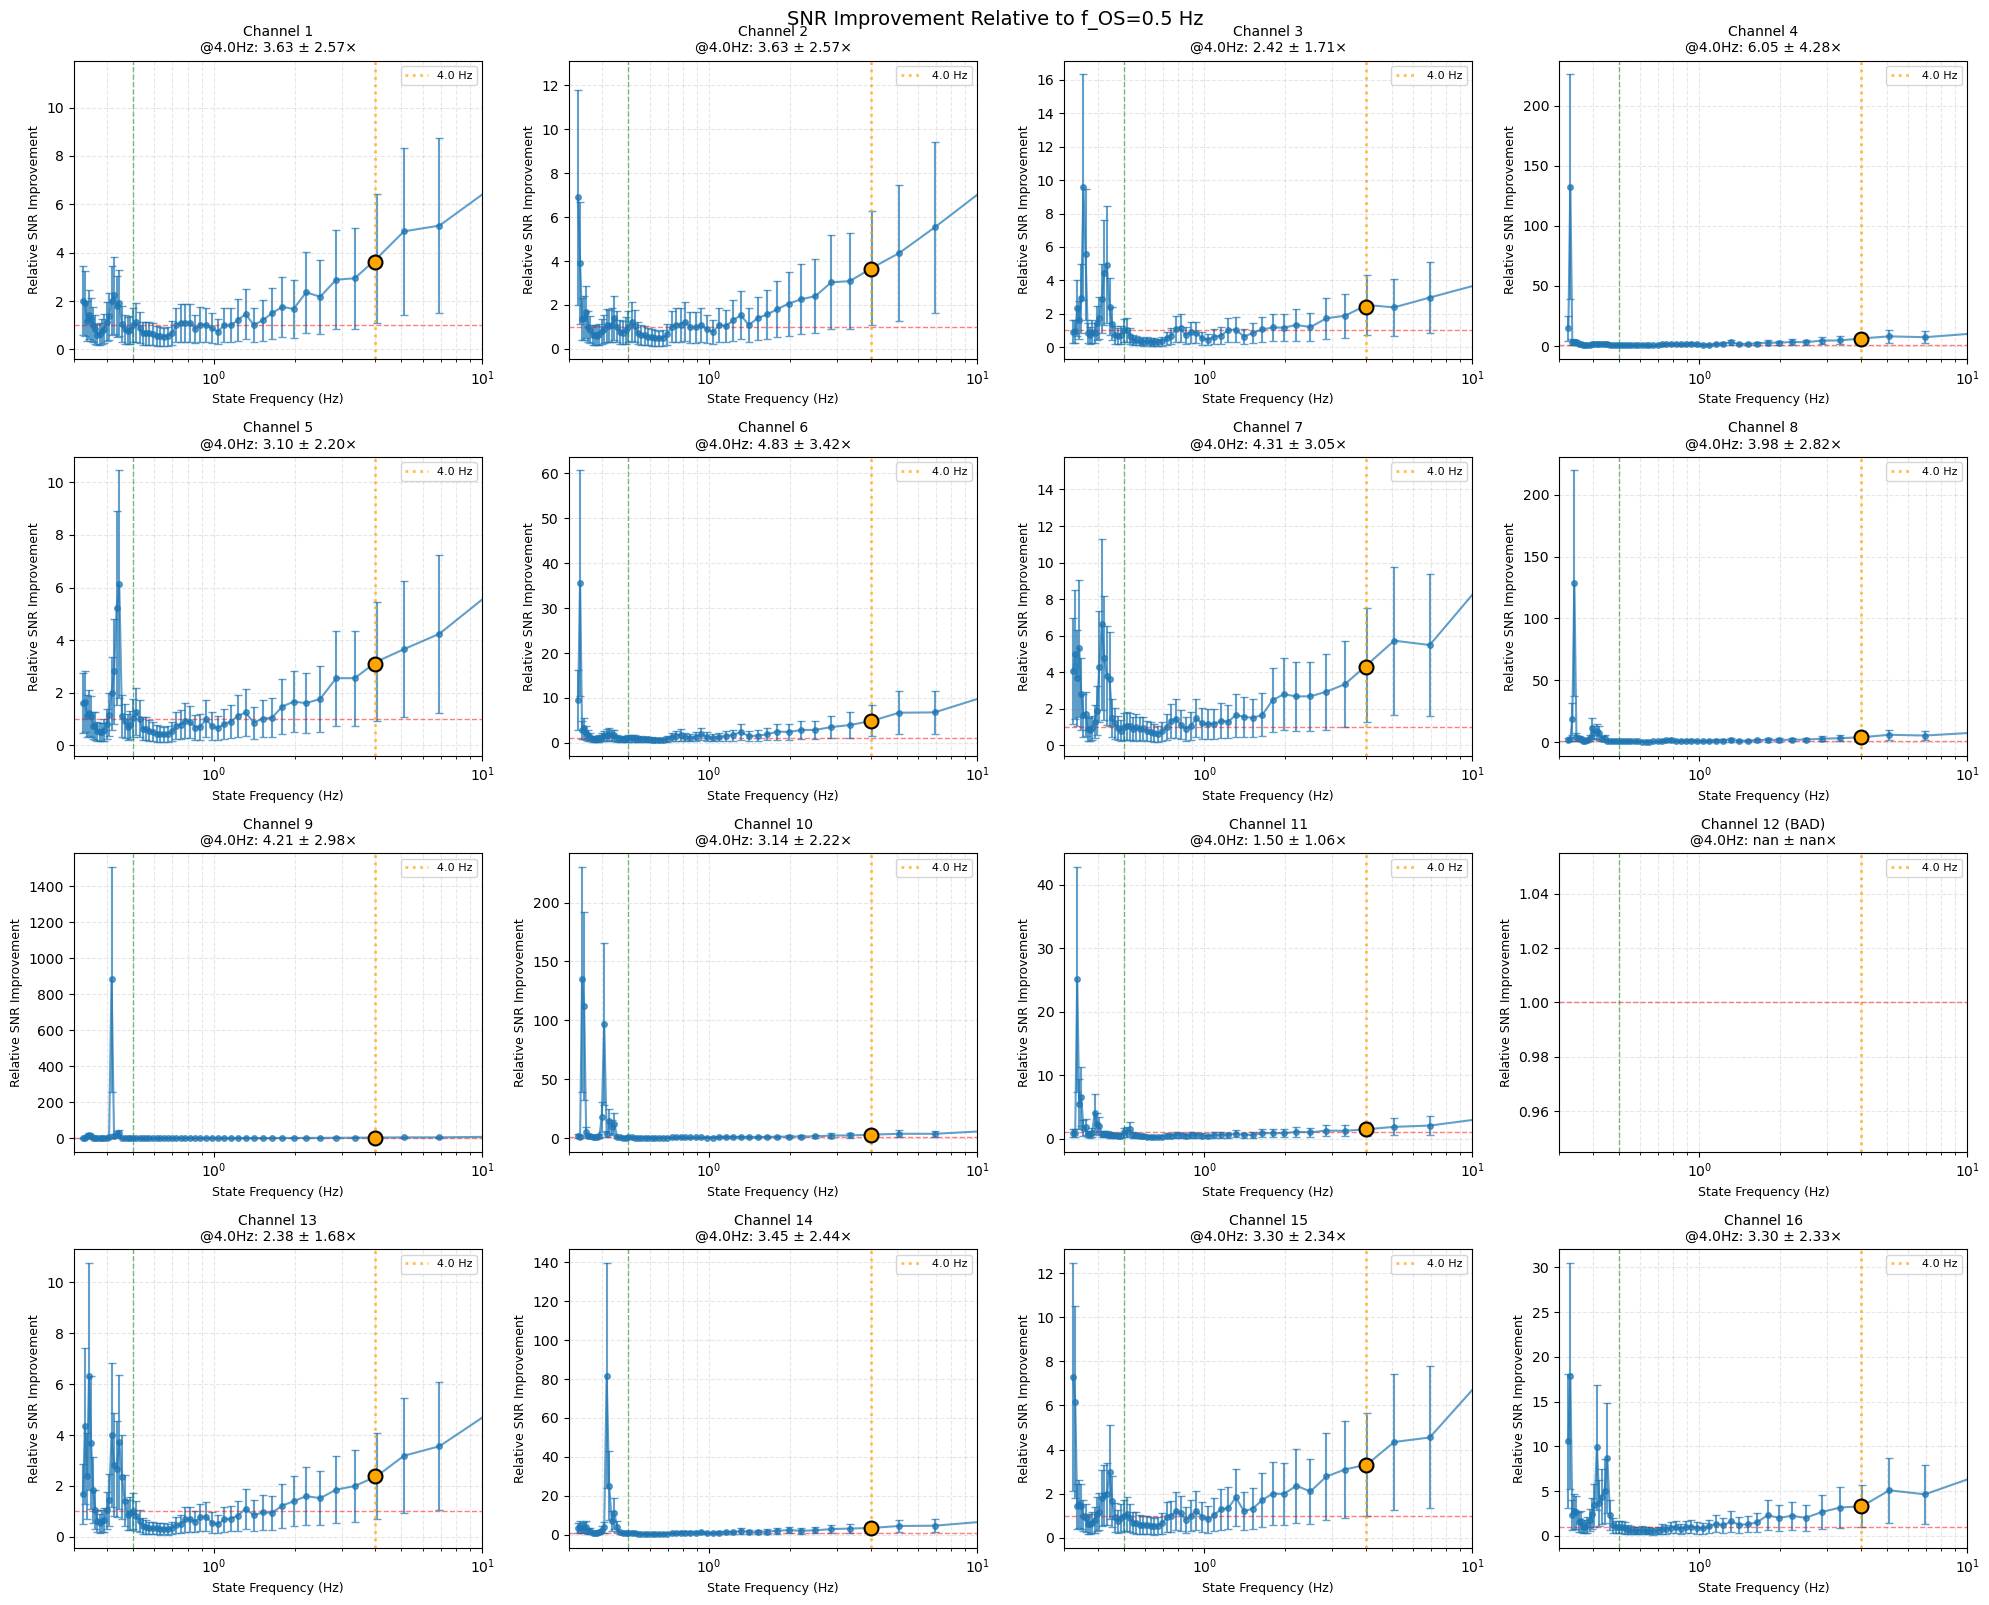

In [62]:
# Plot the improvement at 4 Hz for all channels
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for channel in range(snr_all.shape[0]):
    ax = axes[channel // 4, channel % 4]
    
    relative_improvement = snr_all[channel, :] / snr_at_f_OS[channel]
    sigma_rel_improvement = relative_improvement * np.sqrt(
        (sigma_snr_all[channel, :] / snr_all[channel, :])**2 +
        (sigma_snr_at_f_OS[channel] / snr_at_f_OS[channel])**2
    )
    
    # Plot with error bars (thin out for readability)
    skip = 5
    ax.errorbar(f_state[::-1][::skip], relative_improvement[::skip], 
                yerr=sigma_rel_improvement[::skip],
                marker='o', capsize=3, alpha=0.7, markersize=4)
    
    ax.axhline(1, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(f_OS, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    # Mark the 4 Hz point
    ax.axvline(f_target, color='orange', linestyle=':', linewidth=2, alpha=0.7, 
               label=f'{f_target} Hz')
    ax.plot(f_target, improvement_at_4Hz[channel], 'o', color='orange', 
            markersize=10, markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    
    title_str = f'Channel {channel+1}'
    if channel == 11:
        title_str += ' (BAD)'
    
    # Add improvement at 4 Hz info
    title_str += f'\n@{f_target}Hz: {improvement_at_4Hz[channel]:.2f} ± {sigma_improvement_at_4Hz[channel]:.2f}×'
    
    ax.set_title(title_str, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim(3e-1, 1e1)
    ax.set_xlabel('State Frequency (Hz)', fontsize=9)
    ax.set_ylabel('Relative SNR Improvement', fontsize=9)
    ax.legend(fontsize=8)
    
    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.suptitle(f'SNR Improvement Relative to f_OS={f_OS} Hz', fontsize=14, y=1.00)
plt.show()

In [63]:
def compute_improvement_at_frequency(snr_all, sigma_snr_all, f_state, f_target=4.0, f_OS=0.5):
    """
    Compute SNR improvement at a specific frequency relative to f_OS.
    
    Parameters
    ----------
    snr_all : array (n_channels, n_frequencies)
        SNR values for all channels
    sigma_snr_all : array (n_channels, n_frequencies)
        Uncertainties in SNR
    f_state : array
        State frequencies (must match snr_all dimension)
    f_target : float
        Target frequency to evaluate improvement (default 4.0 Hz)
    f_OS : float
        Reference frequency (default 0.5 Hz)
    
    Returns
    -------
    improvement : array (n_channels,)
        Improvement factor at f_target relative to f_OS for each channel
    sigma_improvement : array (n_channels,)
        Uncertainty in improvement factor
    """
    n_channels = snr_all.shape[0]
    
    # Arrays to store results
    snr_at_f_OS = np.zeros(n_channels)
    sigma_snr_at_f_OS = np.zeros(n_channels)
    snr_at_f_target = np.zeros(n_channels)
    sigma_snr_at_f_target = np.zeros(n_channels)
    improvement = np.zeros(n_channels)
    sigma_improvement = np.zeros(n_channels)
    
    for channel in range(n_channels):
        # Interpolate SNR and its uncertainty at f_OS
        snr_at_f_OS[channel] = np.interp(f_OS, f_state[::-1], snr_all[channel, :])
        sigma_snr_at_f_OS[channel] = np.interp(f_OS, f_state[::-1], sigma_snr_all[channel, :])
        
        # Interpolate SNR and its uncertainty at f_target
        snr_at_f_target[channel] = np.interp(f_target, f_state[::-1], snr_all[channel, :])
        sigma_snr_at_f_target[channel] = np.interp(f_target, f_state[::-1], sigma_snr_all[channel, :])
        
        # Compute improvement: ratio = SNR(f_target) / SNR(f_OS)
        improvement[channel] = snr_at_f_target[channel] / snr_at_f_OS[channel]
        
        # Error propagation for ratio
        sigma_improvement[channel] = improvement[channel] * np.sqrt(
            (sigma_snr_at_f_target[channel] / snr_at_f_target[channel])**2 +
            (sigma_snr_at_f_OS[channel] / snr_at_f_OS[channel])**2
        )
    
    # Print results
    print(f"SNR Improvement at {f_target} Hz (relative to {f_OS} Hz):")
    print("=" * 60)
    for channel in range(len(improvement)):
        if channel == 11:
            print(f"Channel {channel+1:2d}: SKIPPED (bad channel)")
        else:
            delta_m = 2.5 * np.log10(improvement[channel])
            sigma_delta_m = 2.5 / np.log(10) * sigma_improvement[channel] / improvement[channel]
            print(f"Channel {channel+1:2d}: {improvement[channel]:5.2f} ± {sigma_improvement[channel]:4.2f}×  "
                  f"({delta_m:+.2f} ± {sigma_delta_m:.2f} mag)")
    
    print("=" * 60)
    valid_mask = np.arange(len(improvement)) != 11
    print(f"Mean improvement at {f_target} Hz: {np.mean(improvement[valid_mask]):.2f} ± {np.std(improvement[valid_mask]):.2f}×")
    print(f"Median improvement at {f_target} Hz: {np.median(improvement[valid_mask]):.2f}×")
    print("=" * 60)
    
    return improvement, sigma_improvement


# Call the function and get the improvement values
max_improvement, sigma_max_improvement = compute_improvement_at_frequency(
    snr_all, 
    sigma_snr_all, 
    f_state, 
    f_target=4.0, 
    f_OS=0.5
)

# Now max_improvement is ready to use in your next cell!
print(f"\nmax_improvement array shape: {max_improvement.shape}")
print(f"Ready to use in detection limit calculations!")

SNR Improvement at 4.0 Hz (relative to 0.5 Hz):
Channel  1:  3.63 ± 2.57×  (+1.40 ± 0.77 mag)
Channel  2:  3.63 ± 2.57×  (+1.40 ± 0.77 mag)
Channel  3:  2.42 ± 1.71×  (+0.96 ± 0.77 mag)
Channel  4:  6.05 ± 4.28×  (+1.95 ± 0.77 mag)
Channel  5:  3.10 ± 2.20×  (+1.23 ± 0.77 mag)
Channel  6:  4.83 ± 3.42×  (+1.71 ± 0.77 mag)
Channel  7:  4.31 ± 3.05×  (+1.59 ± 0.77 mag)
Channel  8:  3.98 ± 2.82×  (+1.50 ± 0.77 mag)
Channel  9:  4.21 ± 2.98×  (+1.56 ± 0.77 mag)
Channel 10:  3.14 ± 2.22×  (+1.24 ± 0.77 mag)
Channel 11:  1.50 ± 1.06×  (+0.44 ± 0.77 mag)
Channel 12: SKIPPED (bad channel)
Channel 13:  2.38 ± 1.68×  (+0.94 ± 0.77 mag)
Channel 14:  3.45 ± 2.44×  (+1.35 ± 0.77 mag)
Channel 15:  3.30 ± 2.34×  (+1.30 ± 0.77 mag)
Channel 16:  3.30 ± 2.33×  (+1.30 ± 0.77 mag)
Mean improvement at 4.0 Hz: 3.55 ± 1.05×
Median improvement at 4.0 Hz: 3.45×

max_improvement array shape: (16,)
Ready to use in detection limit calculations!


# Improvements for Finding NEOS

## Improvements from fidicual values of sensitivity

In [64]:
import sys 
sys.path.append(os.path.expanduser("~/github/NEATM/neatm"))

In [65]:
import neatm
import astropy.units as u

In [66]:
max_improvement

array([3.62803875, 3.63175839, 2.41529251, 6.04515052, 3.10482547,
       4.83237406, 4.30640352, 3.98108019, 4.21283627, 3.14216591,
       1.50378774,        nan, 2.37558859, 3.45257619, 3.3024748 ,
       3.29956144])

We can get a first order estimate of the new values given MIRSI's old reported sensitivity - 4.0 mJy over a 30 second integration time 

In [67]:
old_limit = 4.0 * u.mJy
new_limit = old_limit/max_improvement  # using channel 14 as an example
# Print all the limits for each channel
print("New detection limits for each channel:")
for channel in range(len(max_improvement)):
    if channel == 11:
        print(f"Channel {channel+1:2d}: SKIPPED (bad channel)")
    else:
        new_limit_channel = old_limit / max_improvement[channel]
        print(f"Channel {channel+1:2d}: {new_limit_channel:.2f})")

New detection limits for each channel:
Channel  1: 1.10 mJy)
Channel  2: 1.10 mJy)
Channel  3: 1.66 mJy)
Channel  4: 0.66 mJy)
Channel  5: 1.29 mJy)
Channel  6: 0.83 mJy)
Channel  7: 0.93 mJy)
Channel  8: 1.00 mJy)
Channel  9: 0.95 mJy)
Channel 10: 1.27 mJy)
Channel 11: 2.66 mJy)
Channel 12: SKIPPED (bad channel)
Channel 13: 1.68 mJy)
Channel 14: 1.16 mJy)
Channel 15: 1.21 mJy)
Channel 16: 1.21 mJy)


Try and visiualize the 

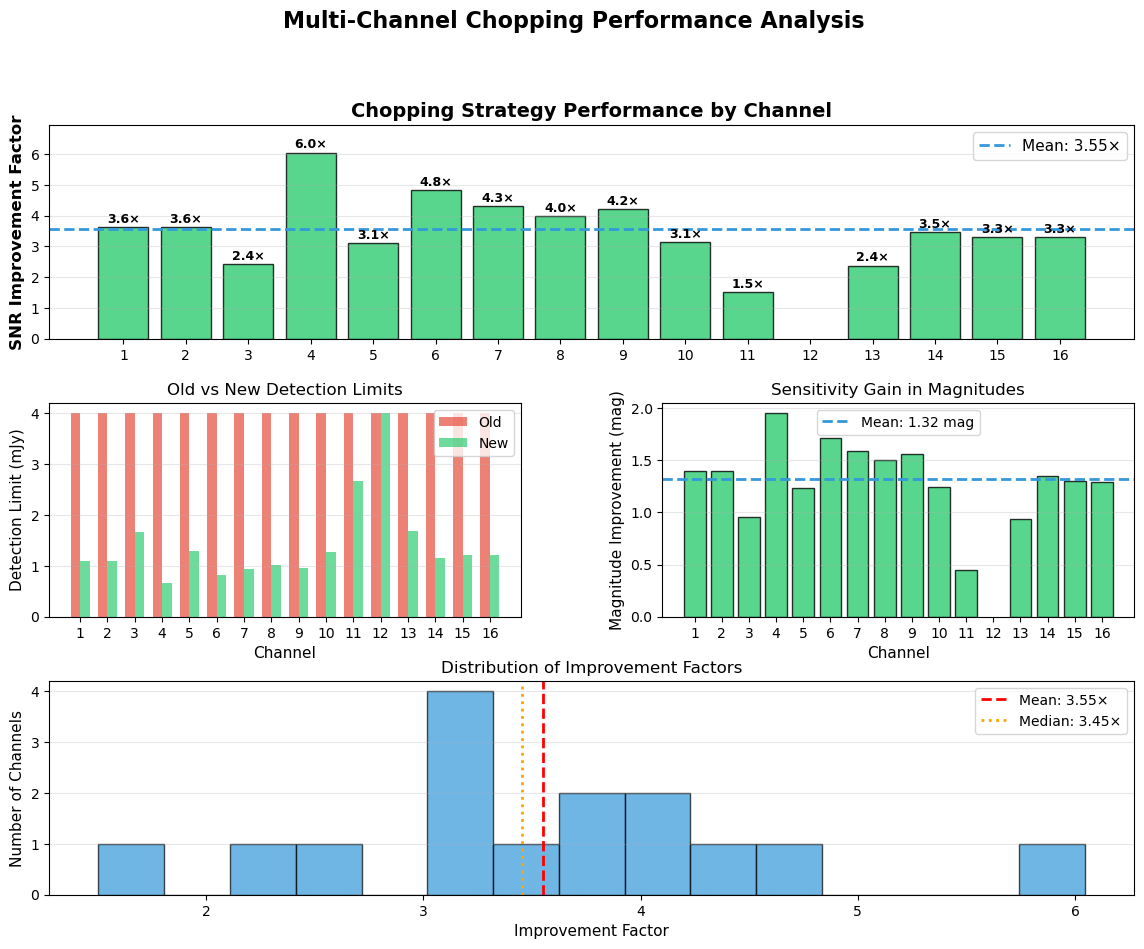


SENSITIVITY IMPROVEMENT SUMMARY
Number of working channels: 15/16

Improvement Factor:
  Mean:   3.55× ± 1.05×
  Median: 3.45×
  Range:  1.50× to 6.05×

Magnitude Improvement:
  Mean:   1.32 ± 0.35 mag
  Median: 1.35 mag

Detection Limit (at 5σ, 60s integration):
  Old:    4.00 mJy
  New:    1.25 ± 0.46 mJy


In [68]:
# Create a comprehensive summary figure
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

channels = np.arange(1, 17)
valid_mask = np.arange(16) != 11
colors = ['#2ecc71' if i != 11 else '#95a5a6' for i in range(16)]

# 1. Improvement factors
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(channels, max_improvement, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.axhline(np.mean(max_improvement[valid_mask]), color='#3498db', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(max_improvement[valid_mask]):.2f}×')
for i, (ch, val) in enumerate(zip(channels, max_improvement)):
    if i != 11:
        ax1.text(ch, val + 0.05, f'{val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylabel('SNR Improvement Factor', fontsize=12, fontweight='bold')
ax1.set_title('Chopping Strategy Performance by Channel', fontsize=14, fontweight='bold')
ax1.set_xticks(channels)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(max_improvement[valid_mask]) * 1.15)

# 2. Old vs New limits
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(channels))
width = 0.35
ax2.bar(x - width/2, old_limit.value * np.ones(16), width, label='Old', 
       color='#e74c3c', alpha=0.7)
new_limits = old_limit.value / max_improvement
new_limits[11] = old_limit.value
ax2.bar(x + width/2, new_limits, width, label='New', color='#2ecc71', alpha=0.7)
ax2.set_ylabel('Detection Limit (mJy)', fontsize=11)
ax2.set_xlabel('Channel', fontsize=11)
ax2.set_title('Old vs New Detection Limits', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(channels)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Magnitude improvement
ax3 = fig.add_subplot(gs[1, 1])
delta_mag = 2.5 * np.log10(max_improvement)
bars = ax3.bar(channels, delta_mag, color=colors, alpha=0.8, edgecolor='black')
ax3.axhline(np.mean(delta_mag[valid_mask]), color='#3498db', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(delta_mag[valid_mask]):.2f} mag')
ax3.set_ylabel('Magnitude Improvement (mag)', fontsize=11)
ax3.set_xlabel('Channel', fontsize=11)
ax3.set_title('Sensitivity Gain in Magnitudes', fontsize=12)
ax3.set_xticks(channels)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Distribution histogram
ax4 = fig.add_subplot(gs[2, :])
valid_improvements = max_improvement[valid_mask]
ax4.hist(valid_improvements, bins=15, color='#3498db', alpha=0.7, edgecolor='black')
ax4.axvline(np.mean(valid_improvements), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(valid_improvements):.2f}×')
ax4.axvline(np.median(valid_improvements), color='orange', linestyle=':', 
           linewidth=2, label=f'Median: {np.median(valid_improvements):.2f}×')
ax4.set_xlabel('Improvement Factor', fontsize=11)
ax4.set_ylabel('Number of Channels', fontsize=11)
ax4.set_title('Distribution of Improvement Factors', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Multi-Channel Chopping Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("SENSITIVITY IMPROVEMENT SUMMARY")
print("="*60)
print(f"Number of working channels: {np.sum(valid_mask)}/16")
print(f"\nImprovement Factor:")
print(f"  Mean:   {np.mean(valid_improvements):.2f}× ± {np.std(valid_improvements):.2f}×")
print(f"  Median: {np.median(valid_improvements):.2f}×")
print(f"  Range:  {np.min(valid_improvements):.2f}× to {np.max(valid_improvements):.2f}×")
print(f"\nMagnitude Improvement:")
print(f"  Mean:   {np.mean(2.5*np.log10(valid_improvements)):.2f} ± {np.std(2.5*np.log10(valid_improvements)):.2f} mag")
print(f"  Median: {np.median(2.5*np.log10(valid_improvements)):.2f} mag")
print(f"\nDetection Limit (at 5σ, 60s integration):")
print(f"  Old:    {old_limit.value:.2f} mJy")
print(f"  New:    {np.mean(old_limit.value/valid_improvements):.2f} ± {np.std(old_limit.value/valid_improvements):.2f} mJy")
print("="*60)

## NEATM Modeling

Now, NEATM will give you an estimate on the expected sensitivity. And perhaps give a range of what asteriods may/may not be detectable. 

From the neatm thermal modeling paper, we use the values for r, delta, and alpha here r - 1.131 au, delta = 0.246 au and alpha = 48.3 deg.

We can use 3200 Phaeton's detectibility as a test. Since we know it's flux in the N-band, 

For the other parameters, we use the same ones as given in Green (1985)

For observations taken on 12-20. 

We also adopt values of q = 0.6 and eta (the emissivity) = 0.9

We use the 4.0 mJy value as a threshold for now. 

From JPL horizons, H = 14.6 for 3200 Phaethon
G is hard to measure so we asume 0.15 


In [69]:
flux = neatm.neatm(
    h=14.6,
    g=0.15,
    alpha=48.3*u.deg,
    r=1.131*u.au,
    delta=0.246*u.au,
    wavelengths=10.*u.um,
    eta=0.9,
    pv=0.135
)

print(flux)

4534.3 mJy


In [70]:
# Conversion
flux_jy = 4500e-3  # 4500 mJy = 4.5 Jy
wavelength_um = 10  # microns (N-band center)

# Formula: F_λ [W/m²/μm] = F_ν [Jy] × 3e-12 / λ²
flux_per_micron = flux_jy * 3e-12 / (wavelength_um**2)

# Convert to log space
log_flux = np.log10(flux_per_micron)

print(f"4500 mJy at {wavelength_um} μm:")
print(f"  Linear: {flux_per_micron:.3e} W/m²/μm")
print(f"  Log:    {log_flux:.3f} log₁₀(W/m²/μm)")

4500 mJy at 10 μm:
  Linear: 1.350e-13 W/m²/μm
  Log:    -12.870 log₁₀(W/m²/μm)


While it is not exactly the values in gree, to OoM it is good enough reliable (probably depends on estiamte of g, eta, and p_v)

In [71]:
def neatm_nband_flux(h, g, alpha, r, delta, eta, pv,
                     lam_min=8.5*u.um, lam_max=13.0*u.um, nlam=100):
    wavelengths = np.linspace(lam_min.value, lam_max.value, nlam) * u.um
    f = neatm.neatm(h, g, alpha, r, delta, wavelengths, eta, pv, mJy=True)
    f = u.Quantity(f)
    return np.mean(f)

In [72]:
def find_limiting_H(flux_limit, g, alpha, r, delta, eta, pv,
                   h_grid=np.linspace(10, 30, 500)):
    """
    Returns the faintest H detectable for a given flux limit.
    
    flux_limit : astropy quantity (e.g., 1 * u.mJy)
    """
    fluxes = []

    for H in h_grid:
        f = neatm_nband_flux(H, g, alpha, r, delta, eta, pv)
        fluxes.append(f.to(u.mJy).value)

    fluxes = np.array(fluxes)

    # Find where flux crosses detection threshold
    idx = np.where(fluxes >= flux_limit.to(u.mJy).value)[0]

    if len(idx) == 0:
        return None  # nothing detectable

    return h_grid[idx[-1]]  # faintest detectable H

In [73]:
def plot_flux_vs_H(g, alpha, r, delta, eta, pv,
                   flux_limits=[5, 2, 1],  # mJy
                   h_grid=np.linspace(10, 30, 200)):

    fluxes = []
    for H in h_grid:
        f = neatm_nband_flux(H, g, alpha, r, delta, eta, pv)
        fluxes.append(f.to(u.mJy).value)

    fluxes = np.array(fluxes)

    plt.figure(figsize=(6,5))
    plt.plot(h_grid, fluxes, label="NEATM prediction")

    for fl in flux_limits:
        plt.axhline(fl, linestyle='--', label=f"{fl} mJy limit")

    plt.yscale('log')
    plt.xlabel("Absolute Magnitude H")
    plt.ylabel("N-band Flux (mJy)")
    plt.legend()
    plt.title(f"r={r}, Δ={delta}, α={alpha}")
    plt.show()

In [74]:
def compare_sensitivity(flux_old, flux_new, g, alpha, r, delta, eta, pv):
    H_old = find_limiting_H(flux_old, g, alpha, r, delta, eta, pv)
    H_new = find_limiting_H(flux_new, g, alpha, r, delta, eta, pv)

    print(f"Old limit H: {H_old:.2f}")
    print(f"New limit H: {H_new:.2f}")
    print(f"Gain in H: {H_new - H_old:.2f} mag")

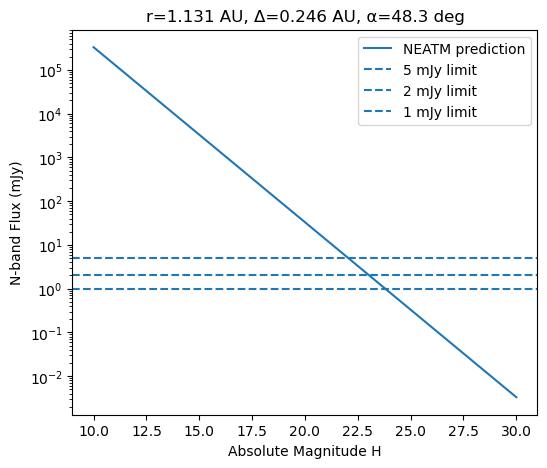

In [75]:
plot_flux_vs_H(g=0.15, alpha=48.3*u.deg, r=1.131*u.au, delta=0.246*u.au, eta=0.9, pv=0.135)

In [76]:
# Example geometry / NEATM parameters
g = 0.15          # asteroid phase slope parameter
alpha = 30       # phase angle, deg
r = 1.1          # heliocentric distance, AU
delta = 0.2      # observer distance, AU
eta = 1.0        # beaming parameter
pv = 0.14        # visible geometric albedo

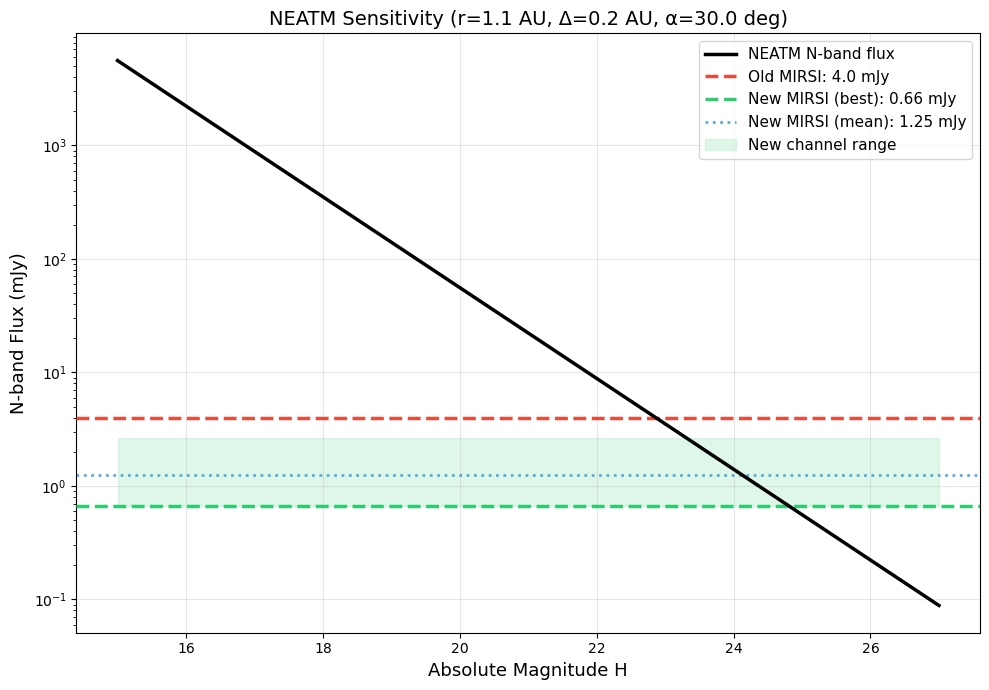


SENSITIVITY COMPARISON:
  Old MIRSI limit:        4.00 mJy
  New MIRSI (best):       0.66 mJy (6.05× better)
  New MIRSI (mean):       1.25 mJy (3.21× better)
  New MIRSI (worst):      2.66 mJy (1.50× better)


In [77]:
def plot_flux_vs_H_realistic(g, alpha, r, delta, eta, pv, h_grid=np.linspace(15, 35, 100)):
    """
    Plot with actual MIRSI sensitivity limits from your analysis.
    """
    fluxes = []
    for H in h_grid:
        f = neatm_nband_flux(H, g, alpha, r, delta, eta, pv)
        fluxes.append(f.to(u.mJy).value)

    fluxes = np.array(fluxes)

    plt.figure(figsize=(10, 7))
    plt.plot(h_grid, fluxes, 'k-', linewidth=2.5, label="NEATM N-band flux", zorder=5)

    # Real limits from your analysis
    valid_channels = np.arange(16) != 11
    new_limits = old_limit.value / max_improvement[valid_channels]
    
    # Old MIRSI limit
    plt.axhline(old_limit.value, linestyle='--', color='#e74c3c', linewidth=2.5, 
                label=f'Old MIRSI: {old_limit.value:.1f} mJy', zorder=3)
    
    # Best new channel
    best_new = np.min(new_limits)
    plt.axhline(best_new, linestyle='--', color='#2ecc71', linewidth=2.5,
                label=f'New MIRSI (best): {best_new:.2f} mJy', zorder=3)
    
    # Mean new performance
    mean_new = np.mean(new_limits)
    plt.axhline(mean_new, linestyle=':', color='#3498db', linewidth=2,
                label=f'New MIRSI (mean): {mean_new:.2f} mJy', alpha=0.8, zorder=2)
    
    # Show range of new limits as shaded region
    plt.fill_between(h_grid, np.min(new_limits), np.max(new_limits), 
                     color='#2ecc71', alpha=0.15, label='New channel range', zorder=1)

    plt.yscale('log')
    plt.xlabel("Absolute Magnitude H", fontsize=13)
    plt.ylabel("N-band Flux (mJy)", fontsize=13)
    plt.legend(fontsize=11, loc='upper right')
    plt.title(f"NEATM Sensitivity (r={r}, Δ={delta}, α={alpha})", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print the improvement stats
    print("\nSENSITIVITY COMPARISON:")
    print(f"  Old MIRSI limit:        {old_limit.value:.2f} mJy")
    print(f"  New MIRSI (best):       {best_new:.2f} mJy ({old_limit.value/best_new:.2f}× better)")
    print(f"  New MIRSI (mean):       {mean_new:.2f} mJy ({old_limit.value/mean_new:.2f}× better)")
    print(f"  New MIRSI (worst):      {np.max(new_limits):.2f} mJy ({old_limit.value/np.max(new_limits):.2f}× better)")

# Use it with your parameters
plot_flux_vs_H_realistic(
    g=g, 
    alpha=alpha*u.deg, 
    r=r*u.au, 
    delta=delta*u.au, 
    eta=eta, 
    pv=pv,
    h_grid=np.linspace(15, 27, 100)
)

This is an okay plot, let's find what this corresponds to in diameter space

/tmp/ipykernel_2060129/955439683.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


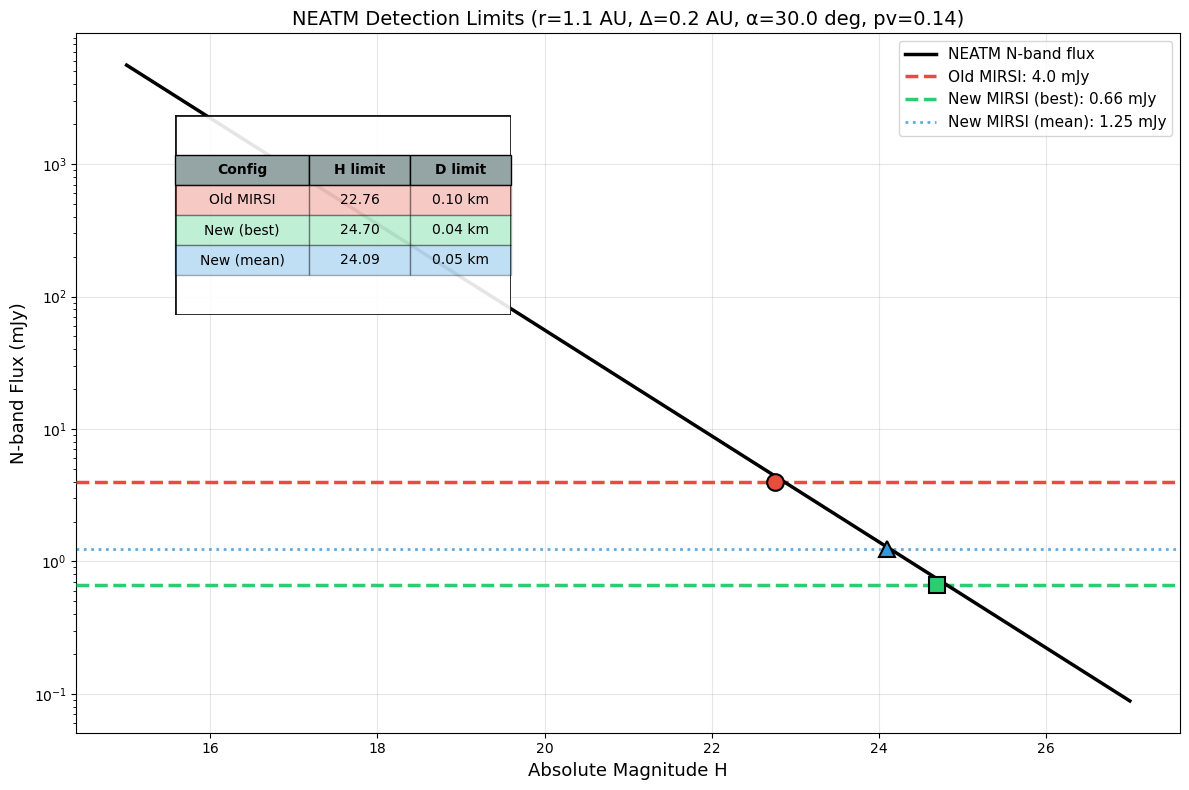


DETECTION LIMIT SUMMARY
Geometry: r=1.1 AU AU, Δ=0.2 AU AU, α=30.0 deg°, pv=0.14

Configuration        Flux Limit      H Limit      Diameter Limit 
--------------------------------------------------------------------------------
Old MIRSI                4.00 mJy     22.76           0.10 km
New (best)               0.66 mJy     24.70           0.04 km
New (mean)               1.25 mJy     24.09           0.05 km
--------------------------------------------------------------------------------
Improvement: Can detect 2.44× smaller asteroids
             Gain of 1.94 mag in H


In [78]:
def plot_flux_vs_H_with_inset_table(g, alpha, r, delta, eta, pv, h_grid=np.linspace(10, 30, 300)):
    """
    Plot with inset table showing detection limits.
    """
    # Compute fluxes
    fluxes = []
    for H in h_grid:
        f = neatm_nband_flux(H, g, alpha, r, delta, eta, pv)
        fluxes.append(f.to(u.mJy).value)
    fluxes = np.array(fluxes)

    # Real limits from your analysis
    valid_channels = np.arange(16) != 11
    new_limits = old_limit.value / max_improvement[valid_channels]
    
    best_new = np.min(new_limits)
    mean_new = np.mean(new_limits)
    
    # Function to convert H to diameter
    def H_to_diameter(H, pv):
        """Convert absolute magnitude to diameter in km."""
        return 1329 / np.sqrt(pv) * 10**(-H/5)
    
    # Find where flux crosses each threshold
    def find_crossing_H(fluxes, h_grid, threshold):
        """Find H magnitude where flux crosses threshold."""
        idx = np.where(fluxes >= threshold)[0]
        if len(idx) == 0:
            return None
        return h_grid[idx[-1]]
    
    # Find crossing points
    H_old = find_crossing_H(fluxes, h_grid, old_limit.value)
    H_best = find_crossing_H(fluxes, h_grid, best_new)
    H_mean = find_crossing_H(fluxes, h_grid, mean_new)
    
    # Convert to diameters
    results = []
    if H_old is not None:
        D_old = H_to_diameter(H_old, pv)
        results.append(('Old MIRSI', old_limit.value, H_old, D_old))
    if H_best is not None:
        D_best = H_to_diameter(H_best, pv)
        results.append(('New (best)', best_new, H_best, D_best))
    if H_mean is not None:
        D_mean = H_to_diameter(H_mean, pv)
        results.append(('New (mean)', mean_new, H_mean, D_mean))
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(h_grid, fluxes, 'k-', linewidth=2.5, label="NEATM N-band flux", zorder=5)

    # Detection limits
    ax.axhline(old_limit.value, linestyle='--', color='#e74c3c', linewidth=2.5, 
                label=f'Old MIRSI: {old_limit.value:.1f} mJy', zorder=3)
    ax.axhline(best_new, linestyle='--', color='#2ecc71', linewidth=2.5,
                label=f'New MIRSI (best): {best_new:.2f} mJy', zorder=3)
    ax.axhline(mean_new, linestyle=':', color='#3498db', linewidth=2,
                label=f'New MIRSI (mean): {mean_new:.2f} mJy', alpha=0.8, zorder=2)
    
    
    # Mark crossing points (just markers, no labels)
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    markers = ['o', 's', '^']
    
    for i, (name, limit, H, D) in enumerate(results):
        ax.plot(H, limit, markers[i], color=colors[i], markersize=12, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=10)

    # Create inset table
    table_data = []
    for name, limit, H, D in results:
        table_data.append([name, f'{H:.2f}', f'{D:.2f} km'])
    
    # Add table as inset
    from matplotlib.patches import Rectangle
    
    # Position the table (adjust these values as needed)
    table_ax = fig.add_axes([0.15, 0.60, 0.28, 0.25])  # [left, bottom, width, height]
    table_ax.axis('tight')
    table_ax.axis('off')
    
    table = table_ax.table(cellText=table_data,
                          colLabels=['Config', 'H limit', 'D limit'],
                          cellLoc='center',
                          loc='center',
                          colWidths=[0.4, 0.3, 0.3])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    
    # Color code the rows
    for i, color in enumerate(colors):
        table[(i+1, 0)].set_facecolor(color)
        table[(i+1, 1)].set_facecolor(color)
        table[(i+1, 2)].set_facecolor(color)
        table[(i+1, 0)].set_alpha(0.3)
        table[(i+1, 1)].set_alpha(0.3)
        table[(i+1, 2)].set_alpha(0.3)
    
    # Header styling
    for i in range(3):
        table[(0, i)].set_facecolor('#95a5a6')
        table[(0, i)].set_text_props(weight='bold')
    
    # Add white background box
    table_ax.add_patch(Rectangle((0, 0), 1, 1, transform=table_ax.transAxes,
                                 facecolor='white', edgecolor='black', 
                                 linewidth=2, alpha=0.9, zorder=-1))

    ax.set_yscale('log')
    ax.set_xlabel("Absolute Magnitude H", fontsize=13)
    ax.set_ylabel("N-band Flux (mJy)", fontsize=13)
    ax.legend(fontsize=11, loc='upper right')
    ax.set_title(f"NEATM Detection Limits (r={r}, Δ={delta}, α={alpha}, pv={pv})", fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*80)
    print("DETECTION LIMIT SUMMARY")
    print("="*80)
    print(f"Geometry: r={r} AU, Δ={delta} AU, α={alpha}°, pv={pv}")
    print(f"\n{'Configuration':<20} {'Flux Limit':<15} {'H Limit':<12} {'Diameter Limit':<15}")
    print("-"*80)
    
    for name, limit, H, D in results:
        print(f"{name:<20} {limit:>8.2f} mJy    {H:>6.2f}       {D:>8.2f} km")
    
    if len(results) >= 2:
        D_improvement = results[0][3] / results[1][3]
        H_improvement = results[1][2] - results[0][2]
        print("-"*80)
        print(f"Improvement: Can detect {D_improvement:.2f}× smaller asteroids")
        print(f"             Gain of {H_improvement:.2f} mag in H")
    
    print("="*80)
    
    return results

# Use the inset table version
results = plot_flux_vs_H_with_inset_table(
    g=g, 
    alpha=alpha*u.deg, 
    r=r*u.au, 
    delta=delta*u.au, 
    eta=eta, 
    pv=pv,
    h_grid=np.linspace(15, 27, 100)
)